# Analyzing Profit Erosion from Product Returns in E-Commerce

## A Multi-Method Analytics Framework

**Course**: DAMO-699-4 - Winter 2026 Capstone Project  
**Institution**: University of Niagara Falls, Canada  
**Professor**: Omid Isfahanialamdari

---

## Research Questions

| RQ | Focus | Method |
|----|-------|--------|
| RQ1 | Profit erosion differences across product categories/brands | Descriptive Analysis |
| RQ2 | Customer behavioral segments with differential profit erosion | Unsupervised Learning (Clustering) |
| RQ3 | Predict high profit erosion customers (target AUC > 0.70) | Predictive Modeling (ML) |
| RQ4 | Marginal associations between behaviors and profit erosion | Econometric Regression |
| RQ5 | Optimal intervention thresholds (Optional) | Prescriptive Analytics |

---

## Key Metrics

- **Margin Reversal**: `sale_price - cost` for returned items
- **Processing Cost**: Estimated cost per return (category-adjusted)
- **Profit Erosion**: `margin_reversal + processing_cost` (for returned items only)

---

## Notebook Structure

1. **Setup** - Environment configuration and module imports
2. **Data Loading** - Build raw merged dataset from source files
3. **Data Cleaning** - Quality validation and flagging
4. **Feature Engineering** - Apply return flags, margins, profit erosion calculations
5. **Descriptive & Group-Level Transformations** - Apply 
6. **RQ1: Descriptive Analysis** - Profit erosion by category/brand
7. **RQ2: Customer Segmentation** - Clustering by return behavior
8. **RQ3: Predictive Modeling** - ML models for high-risk identification
9. **RQ4: Econometric Analysis** - Regression analysis
10. **Summary & Conclusions**

---

## 1. Setup and Imports

In [183]:
# Standard library imports
import sys
from pathlib import Path

# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Reload modules to ensure latest changes are loaded
import importlib
modules_to_reload = [
    'src.config',
    'src.data_processing',
    'src.feature_engineering',
    'src.data_cleaning',
    'src.visualization',
    'src.analytics'
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project configuration
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, PROCESSED_PARQUET

# Data processing (raw data only)
from src.data_processing import (
    load_raw_data,
    merge_datasets,
    standardize_dtypes,
    build_analysis_dataset,
    load_processed_data,
)

# Feature engineering (US06 implementation)
from src.feature_engineering import (
    engineer_return_features,
    calculate_margins,
    calculate_profit_erosion,
    aggregate_profit_erosion_by_order,
    aggregate_profit_erosion_by_customer,
    summarize_profit_erosion,
    engineer_customer_behavioral_features,
    create_profit_erosion_targets,
    save_feature_engineered_dataset,
    CATEGORY_TIER_MULTIPLIERS,
    DEFAULT_COST_COMPONENTS,
)

# Data cleaning
from src.data_cleaning import (
    perform_deep_clean,
    save_cleaned_dataset,
)

#Descriptive Transformations
from src.descriptive_transformations import (
    build_product_profit_erosion_metrics,     # US07 #57
    build_product_return_behavior_metrics,    # US07 #58
    build_customer_profit_erosion_summaries,  # US07 #59
    build_product_modeling_dataset,
    build_customer_modeling_dataset,
)

# Visualization
from src.visualization import (
    set_plot_style,
    plot_status_distribution,
    plot_return_rate_by_category,
    plot_margin_distribution,
    plot_margin_loss_by_category,
    plot_customer_margin_exposure,
    plot_return_rate_heatmap,
    plot_price_margin_returned_by_status_country,
)

# Analytics (descriptive analysis functions)
from src.analytics import (
    calculate_return_rates_by_group,
    calculate_margin_loss_by_group,
    calculate_customer_margin_exposure,
    segment_customers_by_return_behavior,
    calculate_price_margin_returned_by_country,
)

#RQ1 specific modules
from src.rq1_run import run_rq1
from src import rq1_stats
from src import rq1_visuals

# Set plotting style
set_plot_style()

print(f"Project root: {project_root}")
print(f"Raw data dir: {RAW_DATA_DIR}")
print(f"Processed data dir: {PROCESSED_DATA_DIR}")
print("\n✓ All modules loaded successfully")

Project root: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project
Raw data dir: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\raw
Processed data dir: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed

✓ All modules loaded successfully


---

## 2. Data Loading

Build the raw merged dataset from source CSV files. The `build_analysis_dataset()` function:
1. Loads raw CSV files (order_items, orders, products, users)
2. Merges them at order-item grain level
3. Standardizes data types
4. Saves to parquet/csv for future use

In [184]:
# Build raw merged dataset from source files
# This loads, merges, and standardizes types - no feature engineering applied yet
print("Building raw merged dataset from source files...")
df_raw = build_analysis_dataset(save_output=True)

print(f"\nDataset built:")
print(f"  Rows: {len(df_raw):,}")
print(f"  Columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
print(df_raw.columns.tolist())

Building raw merged dataset from source files...

Dataset built:
  Rows: 180,908
  Columns: 40

Column names:
['order_item_id', 'order_id', 'product_id', 'inventory_item_id', 'item_status', 'item_created_at', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'user_id', 'order_created_at', 'order_status', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost', 'category', 'name', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'first_name', 'last_name', 'email', 'age', 'user_gender', 'state', 'street_address', 'postal_code', 'city', 'country', 'latitude', 'longitude', 'traffic_source', 'user_created_at', 'user_geom']


---

## 3. Data Cleaning

Apply comprehensive data quality validation using the data_cleaning module. This step validates and flags issues in the raw data before feature engineering.

In [185]:
# Perform comprehensive deep cleaning on raw data
print("Performing data quality validation...")
print(f"Initial dataset: {len(df_raw):,} rows")

df_cleaned, cleaning_report = perform_deep_clean(
    df_raw,
    remove_duplicates=True,
    handle_missing="report",
    detect_outliers=True,
    validate_prices=True,
    validate_status=True,
    validate_temporal=True,
    clean_categories=True,
    remove_low_variance=False,
    outlier_action="flag",
    price_action="flag",
    status_action="flag",
    temporal_action="flag",
)

print(f"\nCleaned dataset: {len(df_cleaned):,} rows")
print(f"Rows removed: {cleaning_report['summary'].get('rows_removed', 0):,}")
print(f"Outliers flagged: {cleaning_report.get('outliers', {}).get('total_outlier_rows', 0):,}")

Performing data quality validation...
Initial dataset: 180,908 rows

Cleaned dataset: 180,908 rows
Rows removed: 0
Outliers flagged: 63,108


---

## 4. Feature Engineering (US06 Implementation)

Apply feature engineering functions to create analysis-ready columns:

### 4.1 Basic Features
- **Return flags**: `is_returned_item`, `is_returned_order`
- **Margin metrics**: `item_margin`, `item_margin_pct`, `discount_amount`, `discount_pct`

### 4.2 Profit Erosion Metrics (US06 Task 1)
- **Margin reversal**: The margin lost on each returned item
- **Processing cost**: $12 base × category multiplier (Premium 1.3x, Moderate 1.15x, Standard 1.0x)
- **Profit erosion**: margin_reversal + processing_cost

### 4.3 Customer Behavioral Features (US06 Task 2)
- RFM-style metrics: Recency, Frequency, Monetary
- Return behavior: return_frequency, customer_return_rate

### 4.4 Target Variables (US06 Task 5)
- Binary classification: `is_high_erosion_customer` (75th percentile threshold)
- Quartile assignment: `profit_erosion_quartile` (1-4)

In [186]:
# Apply feature engineering to cleaned data
print("=" * 60)
print("4.1 BASIC FEATURE ENGINEERING")
print("=" * 60)

# Step 1: Engineer return features
df = engineer_return_features(df_cleaned)
print(f"✓ Added return flags: is_returned_item, is_returned_order")
print(f"  Return rate: {df['is_returned_item'].mean() * 100:.2f}%")
print(f"  Returned items: {df['is_returned_item'].sum():,}")

# Step 2: Calculate margins
df = calculate_margins(df)
print(f"\n✓ Added margin metrics: item_margin, item_margin_pct, discount_amount, discount_pct")
print(f"  Mean item margin: ${df['item_margin'].mean():.2f}")
print(f"  Total margin: ${df['item_margin'].sum():,.2f}")

print(f"\nDataset after basic features: {len(df):,} rows, {len(df.columns)} columns")

4.1 BASIC FEATURE ENGINEERING
✓ Added return flags: is_returned_item, is_returned_order
  Return rate: 10.06%
  Returned items: 18,208

✓ Added margin metrics: item_margin, item_margin_pct, discount_amount, discount_pct
  Mean item margin: $31.04
  Total margin: $5,615,388.13

Dataset after basic features: 180,908 rows, 52 columns


### 4.2 Profit Erosion Metrics (US06 Task 1)

Calculate profit erosion for returned items using category-tiered processing costs:
- **Base cost**: $12 per return (customer care $4, inspection $2.50, restocking $3, logistics $2.50)
- **Category multipliers**: Premium (1.3x), Moderate (1.15x), Standard (1.0x)

In [187]:
# Display processing cost model
print("=" * 60)
print("4.2 PROFIT EROSION CALCULATION (US06 Task 1)")
print("=" * 60)

print("\n📋 Processing Cost Model:")
print(f"  Base cost: ${sum(DEFAULT_COST_COMPONENTS.values()):.2f} per return")
for component, cost in DEFAULT_COST_COMPONENTS.items():
    print(f"    - {component}: ${cost:.2f}")

print("\n📊 Category Tier Multipliers:")
premium = [k for k, v in CATEGORY_TIER_MULTIPLIERS.items() if v == 1.3]
moderate = [k for k, v in CATEGORY_TIER_MULTIPLIERS.items() if v == 1.15]
standard = [k for k, v in CATEGORY_TIER_MULTIPLIERS.items() if v == 1.0]

print(f"  Premium (1.3x = $15.60): {len(premium)} categories")
print(f"  Moderate (1.15x = $13.80): {len(moderate)} categories")
print(f"  Standard (1.0x = $12.00): {len(standard)} categories")

4.2 PROFIT EROSION CALCULATION (US06 Task 1)

📋 Processing Cost Model:
  Base cost: $12.00 per return
    - customer_care: $4.00
    - inspection: $2.50
    - restocking: $3.00
    - logistics: $2.50

📊 Category Tier Multipliers:
  Premium (1.3x = $15.60): 8 categories
  Moderate (1.15x = $13.80): 9 categories
  Standard (1.0x = $12.00): 9 categories


In [188]:
# Calculate profit erosion for returned items
print("\n🔄 Calculating profit erosion for returned items...")

# Filter to returned items only
df_returned = df[df["is_returned_item"] == 1].copy()
print(f"  Returned items: {len(df_returned):,}")

# Apply profit erosion calculation with category-tiered costs
df_returned = calculate_profit_erosion(df_returned, use_category_tiers=True)

# Verify the calculation
print(f"\n✓ Profit erosion columns added:")
print(f"  - margin_reversal: margin lost on return")
print(f"  - process_cost: ${df_returned['process_cost'].min():.2f} - ${df_returned['process_cost'].max():.2f}")
print(f"  - profit_erosion: margin_reversal + process_cost")

# Show distribution of processing costs by tier
process_cost_dist = df_returned.groupby("process_cost").size()
print(f"\n📊 Processing cost distribution:")
for cost, count in process_cost_dist.items():
    pct = count / len(df_returned) * 100
    print(f"  ${cost:.2f}: {count:,} items ({pct:.1f}%)")


🔄 Calculating profit erosion for returned items...
  Returned items: 18,208

✓ Profit erosion columns added:
  - margin_reversal: margin lost on return
  - process_cost: $12.00 - $15.60
  - profit_erosion: margin_reversal + process_cost

📊 Processing cost distribution:
  $12.00: 5,042 items (27.7%)
  $13.80: 7,604 items (41.8%)
  $15.60: 5,562 items (30.5%)


In [189]:
# Summarize profit erosion
erosion_summary = summarize_profit_erosion(df_returned)

print("\n" + "=" * 60)
print("PROFIT EROSION SUMMARY (Category-Tiered Costs)")
print("=" * 60)
print(f"Total returned items:      {erosion_summary['total_returned']:,}")
print(f"\n💰 Margin Reversal:")
print(f"  Total:                   ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"  Average per return:      ${erosion_summary['avg_margin_per_return']:.2f}")
print(f"  Median per return:       ${erosion_summary['median_margin_per_return']:.2f}")
print(f"  Max single loss:         ${erosion_summary['max_single_margin_loss']:.2f}")
print(f"\n📦 Processing Costs:")
print(f"  Total:                   ${erosion_summary['total_process_costs']:,.2f}")
print(f"\n🔴 TOTAL PROFIT EROSION:   ${erosion_summary['total_profit_erosion']:,.2f}")
print(f"  Average per return:      ${erosion_summary['avg_erosion_per_return']:.2f}")
print("=" * 60)


PROFIT EROSION SUMMARY (Category-Tiered Costs)
Total returned items:      18,208

💰 Margin Reversal:
  Total:                   $564,294.54
  Average per return:      $30.99
  Median per return:       $20.52
  Max single loss:         $535.48

📦 Processing Costs:
  Total:                   $252,206.40

🔴 TOTAL PROFIT EROSION:   $816,500.94
  Average per return:      $44.84


### 4.3 Customer Behavioral Features (US06 Task 2)

Create RFM-style (Recency, Frequency, Monetary) customer features for segmentation and predictive modeling.

In [190]:
# Create customer behavioral features
print("=" * 60)
print("4.3 CUSTOMER BEHAVIORAL FEATURES (US06 Task 2)")
print("=" * 60)

# Generate customer-level features from item-level data
customer_features = engineer_customer_behavioral_features(df)

print(f"\n✓ Created customer behavioral features for {len(customer_features):,} customers")
print(f"\nFeatures created:")
for col in customer_features.columns:
    if col != "user_id":
        print(f"  - {col}")

# Display summary statistics
print("\n📊 Customer Feature Summary:")
customer_features.describe().round(2)

4.3 CUSTOMER BEHAVIORAL FEATURES (US06 Task 2)

✓ Created customer behavioral features for 79,944 customers

Features created:
  - total_items
  - order_frequency
  - return_frequency
  - total_sales
  - total_margin
  - avg_item_price
  - avg_item_margin
  - customer_return_rate
  - avg_basket_size
  - purchase_recency_days
  - customer_tenure_days
  - avg_order_value

📊 Customer Feature Summary:


,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value
count,79944.00,79944.00,79944.00,79944.00,79944.00,79944.00,79944.00,79944.00,79944.00,77852.00,77852.00,79944.00
mean,2.26,1.56,0.23,135.26,70.24,59.95,31.16,0.10,1.45,544.92,1287.43,86.69
std,1.60,0.86,0.64,138.48,74.08,54.00,29.78,0.27,0.72,526.42,743.23,83.27
min,1.00,1.00,0.00,0.49,0.31,0.49,0.31,0.00,1.00,0.00,0.00,0.49
25%,1.00,1.00,0.00,42.00,21.08,29.99,15.00,0.00,1.00,126.00,640.00,35.00
50%,2.00,1.00,0.00,89.50,45.74,46.98,23.59,0.00,1.00,371.00,1290.00,62.49
75%,3.00,2.00,0.00,182.49,94.14,71.97,37.29,0.00,2.00,820.00,1934.00,110.00
max,13.00,4.00,8.00,1733.43,981.56,999.00,568.10,1.00,4.00,2559.00,2570.00,1724.99


In [191]:
# Aggregate profit erosion by customer
print("\n🔄 Aggregating profit erosion to customer level...")

customer_erosion = aggregate_profit_erosion_by_customer(df_returned)
print(f"✓ Customers with returns: {len(customer_erosion):,}")

# Merge customer features with erosion data
customer_df = customer_features.merge(
    customer_erosion[["user_id", "total_margin_reversal", "total_process_cost", "total_profit_erosion"]],
    on="user_id",
    how="left"
)

# Fill NaN for customers without returns (erosion = 0)
customer_df["total_profit_erosion"] = customer_df["total_profit_erosion"].fillna(0)
customer_df["total_margin_reversal"] = customer_df["total_margin_reversal"].fillna(0)
customer_df["total_process_cost"] = customer_df["total_process_cost"].fillna(0)

print(f"\n📊 Customer Profit Erosion Distribution:")
print(f"  Customers with erosion > 0: {(customer_df['total_profit_erosion'] > 0).sum():,}")
print(f"  Mean erosion: ${customer_df['total_profit_erosion'].mean():.2f}")
print(f"  Median erosion: ${customer_df['total_profit_erosion'].median():.2f}")
print(f"  Max erosion: ${customer_df['total_profit_erosion'].max():.2f}")
print(f"  75th percentile: ${customer_df['total_profit_erosion'].quantile(0.75):.2f}")


🔄 Aggregating profit erosion to customer level...
✓ Customers with returns: 11,988

📊 Customer Profit Erosion Distribution:
  Customers with erosion > 0: 11,988
  Mean erosion: $10.21
  Median erosion: $0.00
  Max erosion: $729.29
  75th percentile: $0.00


### 4.4 Target Variables for RQ3 (US06 Task 5)

Create binary classification target for predicting high profit erosion customers:
- **Threshold**: 75th percentile (top 25% = "high erosion")
- **Rationale**: Standard quartile segmentation, operationally feasible for intervention

In [192]:
# Create target variables for predictive modeling
print("=" * 60)
print("4.4 TARGET VARIABLES FOR RQ3 (US06 Task 5)")
print("=" * 60)

# Apply target variable creation (only for customers with erosion > 0)
customer_with_erosion = customer_df[customer_df["total_profit_erosion"] > 0].copy()
customer_targets = create_profit_erosion_targets(
    customer_with_erosion, 
    high_erosion_percentile=0.75
)

print(f"\n✓ Created target variables for {len(customer_targets):,} customers with returns")
print(f"\n📊 Target Variable Distribution:")
print(f"\nis_high_erosion_customer:")
high_erosion_dist = customer_targets["is_high_erosion_customer"].value_counts()
for val, count in high_erosion_dist.items():
    pct = count / len(customer_targets) * 100
    label = "High erosion (top 25%)" if val == 1 else "Normal erosion"
    print(f"  {val} ({label}): {count:,} ({pct:.1f}%)")

print(f"\nprofit_erosion_quartile:")
quartile_dist = customer_targets["profit_erosion_quartile"].value_counts().sort_index()
for q, count in quartile_dist.items():
    pct = count / len(customer_targets) * 100
    print(f"  Q{q}: {count:,} ({pct:.1f}%)")

# Show threshold value
threshold = customer_with_erosion["total_profit_erosion"].quantile(0.75)
print(f"\n💰 High erosion threshold (75th percentile): ${threshold:.2f}")

4.4 TARGET VARIABLES FOR RQ3 (US06 Task 5)

✓ Created target variables for 11,988 customers with returns

📊 Target Variable Distribution:

is_high_erosion_customer:
  0 (Normal erosion): 8,991 (75.0%)
  1 (High erosion (top 25%)): 2,997 (25.0%)

profit_erosion_quartile:
  Q1: 2,997 (25.0%)
  Q2: 2,997 (25.0%)
  Q3: 2,997 (25.0%)
  Q4: 2,997 (25.0%)

💰 High erosion threshold (75th percentile): $85.92


### 4.5 Save Feature-Engineered Dataset

Save the complete feature-engineered dataset for downstream analysis.

In [193]:
# Save feature-engineered datasets
print("=" * 60)
print("4.5 SAVE FEATURE-ENGINEERED DATASETS")
print("=" * 60)

# Save item-level dataset with all features
parquet_path, csv_path = save_feature_engineered_dataset(
    df, 
    filename="feature_engineered_dataset",
    save_csv=True,
    save_parquet=True
)
print(f"\n✓ Item-level dataset saved:")
print(f"  Parquet: {parquet_path}")
print(f"  CSV: {csv_path}")
print(f"  Rows: {len(df):,}")

# Save customer-level dataset with targets
customer_parquet, customer_csv = save_feature_engineered_dataset(
    customer_targets,
    filename="customer_profit_erosion_targets",
    save_csv=True,
    save_parquet=True
)
print(f"\n✓ Customer-level dataset saved:")
print(f"  Parquet: {customer_parquet}")
print(f"  CSV: {customer_csv}")
print(f"  Rows: {len(customer_targets):,}")

print("\n" + "=" * 60)
print("✅ US06 FEATURE ENGINEERING COMPLETE")
print("=" * 60)

4.5 SAVE FEATURE-ENGINEERED DATASETS

✓ Item-level dataset saved:
  Parquet: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\feature_engineered_dataset.parquet
  CSV: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\feature_engineered_dataset.csv
  Rows: 180,908

✓ Customer-level dataset saved:
  Parquet: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\customer_profit_erosion_targets.parquet
  CSV: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\customer_profit_erosion_targets.csv
  Rows: 11,988

✅ US06 FEATURE ENGINEERING COMPLETE


---
## 5. Descriptive & Group-Level Transformations

**Purpose:** US07 produces standardized **descriptive transformation artifacts** used downstream by:
- RQ1 (product drivers: category/brand/department)
- RQ2 (customer-level erosion summaries)

**Design rule:**
- This notebook cell block performs **no manual aggregation**.
- It calls **US07 transformation functions** as the single source of truth.
- Outputs are written to: `data/processed/us07/` as **parquet**.


## 5.1  Setup Imports and Project Paths

This cell:
- Locates repo root (folder containing `src/`)
- Ensures `from src...` imports work
- Creates the US07 output directory under `data/processed/us07/`


In [194]:
import sys
from pathlib import Path

import pandas as pd

# --- Locate project root (folder containing src/) ---
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root.parent != project_root:
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise RuntimeError("Cannot find project root containing src directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# --- Project imports ---
from src.config import PROCESSED_DATA_DIR
from src.descriptive_transformations import (
    build_product_profit_erosion_metrics,     # US07 #57
    build_product_return_behavior_metrics,    # US07 #58
    build_customer_profit_erosion_summaries,  # US07 #59
)

# --- Output directory for US07 ---
us07_dir = PROCESSED_DATA_DIR
us07_dir.mkdir(parents=True, exist_ok=True)

print("✅ Project root:", project_root)
print("✅ Processed data dir:", PROCESSED_DATA_DIR)
print("✅ US07 output dir:", us07_dir)


✅ Project root: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project
✅ Processed data dir: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed
✅ US07 output dir: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed


## 5.2 Load Processed Dataset (CI-safe)

US07 reads only from `data/processed/` parquet outputs.

Preferred input:
- `returns_eda_v1.parquet` (return-ready, includes `is_returned_item`, product columns, and margins)

Fallback:
- `feature_engineered_dataset.parquet` (if your pipeline uses a different standard name)



In [195]:
candidate_files = [
    PROCESSED_DATA_DIR / "returns_eda_v1.parquet",
    PROCESSED_DATA_DIR / "feature_engineered_dataset.parquet",
]

input_file = None
for f in candidate_files:
    if f.exists():
        input_file = f
        break

if input_file is None:
    raise FileNotFoundError(
        "No processed parquet found in data/processed/. "
        "Expected one of: returns_eda_v1.parquet or feature_engineered_dataset.parquet"
    )

df = pd.read_parquet(input_file)

print(f"✅ Loaded: {input_file.name}")
print(f"   Rows: {len(df):,} | Cols: {df.shape[1]:,}")
print("   Columns (sample):", list(df.columns)[:30])


✅ Loaded: returns_eda_v1.parquet
   Rows: 180,908 | Cols: 40
   Columns (sample): ['order_item_id', 'order_id', 'product_id', 'inventory_item_id', 'item_status', 'item_created_at', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'user_id', 'order_created_at', 'order_status', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost', 'category', 'name', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'first_name', 'last_name', 'email', 'age', 'user_gender']


## 5.3 Product-level Profit Erosion Metrics (Task 1)

This transformation produces erosion metrics grouped by:
- category
- brand
- department

Outputs are written as parquet files to `data/processed/`.

**Note:** Profit erosion is computed on returned items only (per US06 contract).
Return-rate context is included from the analytics layer.



In [196]:
# -------------------------------------------------------------
# US07 #57 — Product-Level Profit Erosion Metrics
# -------------------------------------------------------------
# This cell builds and persists product-level erosion tables
# using processed data only (CI-safe, reproducible).
# -------------------------------------------------------------

import importlib
import src.descriptive_transformations as dt

# Reload module to ensure latest version is used
importlib.reload(dt)

# Output directory (strict location)
us07_dir = PROCESSED_DATA_DIR
us07_dir.mkdir(parents=True, exist_ok=True)

# Build metrics
product_erosion = dt.build_product_profit_erosion_metrics(df)

erosion_cat = product_erosion["by_category"].copy()
erosion_brand = product_erosion["by_brand"].copy()
erosion_dept = product_erosion["by_department"].copy()

# Sanity validation
if erosion_cat.empty or erosion_brand.empty:
    raise ValueError("US07 output is empty. Check processed dataset.")

# Persist artifacts
erosion_cat.to_parquet(us07_dir / "us07_product_profit_erosion_by_category.parquet", index=False)
erosion_brand.to_parquet(us07_dir / "us07_product_profit_erosion_by_brand.parquet", index=False)
erosion_dept.to_parquet(us07_dir / "us07_product_profit_erosion_by_department.parquet", index=False)

print("✅ Saved US07 #57 outputs:")
print("-", us07_dir / "us07_product_profit_erosion_by_category.parquet")
print("-", us07_dir / "us07_product_profit_erosion_by_brand.parquet")
print("-", us07_dir / "us07_product_profit_erosion_by_department.parquet")

print("\nAudit Summary:")
print("Category shape:", erosion_cat.shape)
print("Brand shape:", erosion_brand.shape)
print("Department shape:", erosion_dept.shape)

erosion_cat.head(5)


✅ Saved US07 #57 outputs:
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_product_profit_erosion_by_category.parquet
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_product_profit_erosion_by_brand.parquet
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_product_profit_erosion_by_department.parquet

Audit Summary:
Category shape: (26, 11)
Brand shape: (182, 11)
Department shape: (2, 11)


,category,item_rows,returned_items,return_rate,returned_item_rows,total_profit_erosion,mean_profit_erosion_per_return,median_profit_erosion_per_return,var_profit_erosion_per_return,total_margin_reversal,total_process_cost
15,Outerwear & Coats,9404,21,0.002233,21.0,1953.772410,93.036781,74.170698,3599.253067,1626.172410,327.6
14,Sweaters,11132,27,0.002425,27.0,1600.576300,59.280604,43.569550,1801.450641,1179.376300,421.2
17,Jeans,12480,26,0.002083,26.0,1380.874187,53.110546,41.236550,682.559878,975.274187,405.6
5,Suits & Sport Coats,4995,15,0.003003,15.0,1348.246719,89.883115,64.209598,5295.511405,1114.246719,234.0
4,Pants,7140,24,0.003361,24.0,1231.365389,51.306891,38.394301,981.525269,856.965389,374.4


## 5.4 Product-level Return Behavior Metrics (Task 2)

This transformation produces return behavior tables (counts + return rate context)
grouped by:
- category
- brand
- department (if available)

Outputs are written to `data/processed/us07/` as parquet.


In [197]:
# -------------------------------------------------------------
# US07 #58 — Product-Level Return Behavior Metrics
# -------------------------------------------------------------
# Builds product return behavior tables using processed dataset.
# Outputs saved to data/processed/us07 (CI-safe).
# -------------------------------------------------------------

import importlib
import src.descriptive_transformations as dt

# Reload module to ensure latest version is used
importlib.reload(dt)

# Ensure output directory exists
us07_dir = PROCESSED_DATA_DIR
us07_dir.mkdir(parents=True, exist_ok=True)

# Build behavior metrics
product_behavior = dt.build_product_return_behavior_metrics(df)

behavior_cat = product_behavior["by_category"].copy()
behavior_brand = product_behavior["by_brand"].copy()

# Sanity validation
if behavior_cat.empty or behavior_brand.empty:
    raise ValueError("US07 #58 output is empty. Check processed dataset.")

# Persist artifacts
behavior_cat.to_parquet(us07_dir / "us07_product_return_behavior_by_category.parquet", index=False)
behavior_brand.to_parquet(us07_dir / "us07_product_return_behavior_by_brand.parquet", index=False)

print("✅ Saved US07 #58 outputs:")
print("-", us07_dir / "us07_product_return_behavior_by_category.parquet")
print("-", us07_dir / "us07_product_return_behavior_by_brand.parquet")

# Optional: department
if "by_department" in product_behavior:
    behavior_dept = product_behavior["by_department"].copy()
    behavior_dept.to_parquet(
        us07_dir / "us07_product_return_behavior_by_department.parquet",
        index=False,
    )
    print("-", us07_dir / "us07_product_return_behavior_by_department.parquet")

print("\nAudit Summary:")
print("Category shape:", behavior_cat.shape)
print("Brand shape:", behavior_brand.shape)

behavior_cat.head(5)


✅ Saved US07 #58 outputs:
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_product_return_behavior_by_category.parquet
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_product_return_behavior_by_brand.parquet
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_product_return_behavior_by_department.parquet

Audit Summary:
Category shape: (26, 4)
Brand shape: (182, 4)


,category,item_rows,returned_items,return_rate
0,Clothing Sets,211,2,0.009479
1,Socks,6114,23,0.003762
2,Maternity,5167,18,0.003484
3,Socks & Hosiery,3796,13,0.003425
4,Pants,7140,24,0.003361


## 5.5 Customer-level Profit Erosion Summaries (Task 3)

This transformation produces a customer analytical table used by RQ2, including:
- `total_profit_erosion`
- `avg_profit_erosion_per_return`
- `return_rows`

The output is written to `data/processed/us07/` as parquet.


In [198]:
# -------------------------------------------------------------
# US07 #59 — Customer-Level Profit Erosion Summaries
# -------------------------------------------------------------
# Builds customer-level erosion summary table from processed data.
# Output saved to data/processed/us07 (CI-safe).
# -------------------------------------------------------------

import importlib
import src.descriptive_transformations as dt

# Reload module to ensure latest version is used
importlib.reload(dt)

# Ensure output directory exists
us07_dir = PROCESSED_DATA_DIR
us07_dir.mkdir(parents=True, exist_ok=True)

# Build customer summary
customer_summary = dt.build_customer_profit_erosion_summaries(df)

# Sanity validation
if customer_summary.empty:
    raise ValueError("US07 #59 output is empty. Check processed dataset.")

# Persist artifact
out_path = us07_dir / "us07_customer_profit_erosion_summaries.parquet"
customer_summary.to_parquet(out_path, index=False)

print("Saved US07 #59 output:")
print("-", out_path)

print("\nAudit Summary:")
print("Customer summary shape:", customer_summary.shape)
print("Columns:", list(customer_summary.columns))

customer_summary.head(5)


Saved US07 #59 output:
- d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\us07_customer_profit_erosion_summaries.parquet

Audit Summary:
Customer summary shape: (294, 4)
Columns: ['user_id', 'return_rows', 'total_profit_erosion', 'avg_profit_erosion_per_return']


,user_id,return_rows,total_profit_erosion,avg_profit_erosion_per_return
228,81807,4,457.303290,114.325823
35,19958,5,365.332273,73.066455
172,63958,3,305.699330,101.899777
181,67548,8,305.647640,38.205955
101,41595,2,303.920000,151.960000


## 5.6 —  Completion Summary

This cell confirms that all US07 artifacts exist and are ready for downstream use (RQ1, RQ2).

Build + save US07 #60 base datasets (single cell)

Assumes df already exists (your denormalized item-level dataset).

Quick sanity checks for model base datasets

In [199]:
import importlib
import src.model_ready_views as mrv

importlib.reload(mrv)

us07_dir = PROCESSED_DATA_DIR
us07_dir.mkdir(parents=True, exist_ok=True)

expected = [
    "us07_product_profit_erosion_by_category.parquet",
    "us07_product_profit_erosion_by_brand.parquet",
    "us07_product_profit_erosion_by_department.parquet",
    "us07_product_return_behavior_by_category.parquet",
    "us07_product_return_behavior_by_brand.parquet",
    "us07_customer_profit_erosion_summaries.parquet",
]

missing = [f for f in expected if not (us07_dir / f).exists()]
if missing:
    raise FileNotFoundError(f"US07 outputs missing: {missing}")

print("✅ US07 complete. All expected outputs are present in:", us07_dir)
for f in expected:
    print(" -", f)

outputs = mrv.write_us07_task_60_outputs(df)  # writes ONLY under data/processed/

print("✅ Saved US07 #60 outputs:")
for name, path in outputs.items():
    print("-", name, "->", path)

rq2_base = pd.read_parquet("data/processed/rq2_customer_segmentation_base.parquet")
rq3_base = pd.read_parquet("data/processed/rq3_item_return_classification_base.parquet")
rq4_base = pd.read_parquet("data/processed/rq4_returned_item_profit_erosion_base.parquet")

print("RQ2 base shape:", rq2_base.shape)
print("RQ3 base shape:", rq3_base.shape)
print("RQ4 base shape:", rq4_base.shape)

display(rq2_base.head(5))
display(rq3_base.head(5))
display(rq4_base.head(5))


✅ US07 complete. All expected outputs are present in: d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed
 - us07_product_profit_erosion_by_category.parquet
 - us07_product_profit_erosion_by_brand.parquet
 - us07_product_profit_erosion_by_department.parquet
 - us07_product_return_behavior_by_category.parquet
 - us07_product_return_behavior_by_brand.parquet
 - us07_customer_profit_erosion_summaries.parquet
✅ Saved US07 #60 outputs:
- rq2_customer_segmentation_base -> data\processed\rq2_customer_segmentation_base.parquet
- rq3_item_return_classification_base -> data\processed\rq3_item_return_classification_base.parquet
- rq4_returned_item_profit_erosion_base -> data\processed\rq4_returned_item_profit_erosion_base.parquet
RQ2 base shape: (79944, 12)
RQ3 base shape: (180908, 37)
RQ4 base shape: (443, 41)


,user_id,total_items,returned_items,total_profit_erosion,return_rate,avg_profit_erosion_per_return,age,user_gender,country,state,city,traffic_source
0,81807,11,4,402.103290,0.363636,100.525823,50,M,Japan,Tokyo,Tokyo,Organic
1,19958,7,5,290.932273,0.714286,58.186455,45,M,United States,California,Oxnard,Search
2,41595,7,2,272.720000,0.285714,136.360000,32,F,South Korea,Gyeonggi-do,Namyangju City,Search
3,63958,3,3,260.699330,1.000000,86.899777,32,M,China,Hunan,Barin Guo Yu Mongolu Autonomous Prefecture,Search
4,63925,4,1,255.480999,0.250000,255.480999,51,M,Brasil,Minas Gerais,Belo Horizonte,Search


,order_item_id,order_id,product_id,inventory_item_id,item_created_at,item_shipped_at,item_delivered_at,sale_price,user_id,order_created_at,...,street_address,postal_code,city,country,latitude,longitude,traffic_source,user_created_at,user_geom,is_returned_item
0,110641,76414,14235,298798,2024-11-21 23:08:55+00:00,NaT,NaT,0.02,61335,2024-11-19 00:44:19+00:00,...,36502 Paul Ville,730031,Xiamen,China,36.054103,103.810039,Organic,2024-11-08 18:12:00+00:00,POINT(103.8100391 36.05410331),0
1,7853,5466,14235,21307,2025-06-23 17:19:15+00:00,2025-06-24 18:11:46+00:00,2025-06-26 01:55:46+00:00,0.02,4461,2025-06-23 18:55:46+00:00,...,3341 Marie Junction Suite 304,36199,Fuzhou,China,38.446632,112.727120,Organic,2025-05-23 11:47:00+00:00,POINT(112.7271198 38.44663152),0
2,114425,79025,14235,309053,2025-12-22 06:18:07+00:00,2025-12-25 00:54:06+00:00,2025-12-26 03:59:06+00:00,0.02,63450,2025-12-22 07:44:06+00:00,...,27809 Allen Shoals Suite 716,28320,Pinto,Spain,40.246905,-3.685632,Search,2025-07-10 00:11:00+00:00,POINT(-3.685632436 40.24690462),0
3,167396,115509,14235,452082,2022-04-28 14:34:03+00:00,2022-04-25 13:35:52+00:00,2022-04-27 02:46:52+00:00,0.02,92500,2022-04-24 14:37:52+00:00,...,506 Nicholas Village,95680-000,Canela,Brasil,-29.351238,-50.775911,Search,2020-12-15 15:48:00+00:00,POINT(-50.77591148 -29.35123809),0
4,9435,6560,14235,25590,2022-07-23 04:49:36+00:00,NaT,NaT,0.02,5325,2022-07-19 04:40:53+00:00,...,120 Angela Rapid,201210,Shenyang,China,31.209261,121.649492,Search,2020-04-07 17:53:00+00:00,POINT(121.6494925 31.20926075),0


,order_item_id,order_id,product_id,inventory_item_id,item_status,item_created_at,item_shipped_at,item_delivered_at,sale_price,user_id,...,city,country,latitude,longitude,traffic_source,user_created_at,user_geom,is_returned_item,item_margin,profit_erosion
0,12937,8972,14159,35061,Returned,NaT,NaT,NaT,0.49,7269,...,Los Angeles,United States,34.291843,-118.508546,Search,NaT,POINT(-118.5085463 34.29184312),1,0.31262,0.31262
1,171906,118656,12689,464259,Returned,NaT,NaT,NaT,3.67,94976,...,Canela,Brasil,-29.351238,-50.775911,Search,NaT,POINT(-50.77591148 -29.35123809),1,1.73224,1.73224
2,151138,104310,9164,408065,Returned,NaT,NaT,NaT,3.99,83587,...,Luis Eduardo Magalhães,Brasil,-12.200360,-46.013849,Search,NaT,POINT(-46.01384898 -12.20035985),1,2.20248,2.20248
3,93923,64874,28922,253633,Returned,NaT,NaT,NaT,5.29,52034,...,Hefei,China,22.616703,113.866959,Search,NaT,POINT(113.8669595 22.61670282),1,3.39618,3.39618
4,104079,71871,5930,281142,Returned,NaT,NaT,NaT,6.95,57694,...,Cheonan City,South Korea,36.873974,127.195195,Search,NaT,POINT(127.1951948 36.87397376),1,2.93985,2.93985


---
# 6. RQ1: Product-Level Drivers of Profit Erosion

**Research Question (RQ1):**  
Which product-level dimensions (category, brand, department) are associated with higher profit erosion, and do these differences remain statistically significant?

This section uses:
- **US07** aggregations for descriptive summaries and visuals
- A **returned-items-only** item-level dataset for inferential statistical tests

**Output policy (Notebook):**
- All parquet/csv outputs created in this notebook are saved under: `notebooks/data/processed/rq1/`
- All figures are saved under: `figures/rq1/`




In [220]:
# ============================================================
# Step 1 — Environment setup and output directories
# ============================================================

import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np

# Install dependencies in ONE cell (safe to rerun)
%pip -q install pandas pyarrow matplotlib scipy statsmodels scikit-posthocs

# Resolve repo root (must contain src/)
cwd = Path.cwd().resolve()
project_root = cwd
while not (project_root / "src").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if not (project_root / "src").exists():
    raise RuntimeError("Cannot find project root containing 'src/' directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Notebook outputs -> notebooks/data/processed/rq1/
RQ1_OUT_DIR = project_root / "data" / "processed" / "rq1"
RQ1_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Figures -> figures/rq1/
RQ1_FIG_DIR = project_root / "figures" / "rq1"
RQ1_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("RQ1 outputs:", RQ1_OUT_DIR)
print("RQ1 figures:", RQ1_FIG_DIR)


Note: you may need to restart the kernel to use updated packages.
Project root: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project
RQ1 outputs: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1
RQ1 figures: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1


## 6.1 Import RQ1 Modules

This cell imports:
- `descriptive_transformations` (US07 aggregations)
- `rq1_visuals` (standardized RQ1 plotting utilities)
- `rq1_stats` (RQ1 inferential tests: ANOVA/Kruskal + effect size + optional posthoc)

During development, we reload modules to ensure the notebook uses the latest code.


In [246]:
import src.descriptive_transformations as dt
import src.rq1_visuals as rq1_visuals
import src.rq1_stats as rq1_stats

importlib.reload(dt)
importlib.reload(rq1_visuals)
importlib.reload(rq1_stats)

from IPython.display import display, Image
import matplotlib.pyplot as plt

print("✅ rq1_visuals loaded.")


print("✅ Imported + reloaded dt, rq1_visuals, rq1_stats")


✅ rq1_visuals loaded.
✅ Imported + reloaded dt, rq1_visuals, rq1_stats


## 6.2 Build RQ1 Product-Level Erosion Aggregates (US07 #57)

We generate RQ1 product-group summaries from the denormalized item-level dataset `df`
(which should already exist from earlier pipeline steps in the notebook).

Outputs saved to:
- `data/processed/rq1/rq1_product_profit_erosion_by_category.parquet`
- `data/processed/rq1/rq1_product_profit_erosion_by_brand.parquet`
- `data/processed/rq1/rq1_product_profit_erosion_by_department.parquet`




In [222]:
# Assumes df already exists in the notebook (denormalized engineered dataset)
product_erosion = dt.build_product_profit_erosion_metrics(df)

erosion_cat = product_erosion["by_category"].copy()
erosion_brand = product_erosion["by_brand"].copy()
erosion_dept = product_erosion["by_department"].copy()

erosion_cat.to_parquet(RQ1_OUT_DIR / "rq1_product_profit_erosion_by_category.parquet", index=False)
erosion_brand.to_parquet(RQ1_OUT_DIR / "rq1_product_profit_erosion_by_brand.parquet", index=False)
erosion_dept.to_parquet(RQ1_OUT_DIR / "rq1_product_profit_erosion_by_department.parquet", index=False)

print("✅ Saved RQ1 aggregates to notebook outputs folder.")
erosion_cat.head(5)


✅ Saved RQ1 aggregates to notebook outputs folder.


,category,item_rows,returned_items,return_rate,returned_item_rows,total_profit_erosion,mean_profit_erosion_per_return,median_profit_erosion_per_return,var_profit_erosion_per_return,total_margin_reversal,total_process_cost
15,Outerwear & Coats,9404,21,0.002233,21.0,1953.772410,93.036781,74.170698,3599.253067,1626.172410,327.6
14,Sweaters,11132,27,0.002425,27.0,1600.576300,59.280604,43.569550,1801.450641,1179.376300,421.2
17,Jeans,12480,26,0.002083,26.0,1380.874187,53.110546,41.236550,682.559878,975.274187,405.6
5,Suits & Sport Coats,4995,15,0.003003,15.0,1348.246719,89.883115,64.209598,5295.511405,1114.246719,234.0
4,Pants,7140,24,0.003361,24.0,1231.365389,51.306891,38.394301,981.525269,856.965389,374.4


## 6.4 Prepare Returned-Items Dataset for Inferential Testing

RQ1 statistical tests require an item-level dataset of **returned items only**, with:
- `profit_erosion` (numeric outcome)
- `category` and `brand` (grouping factors)
- a reliable returned-item indicator (`is_returned_item`)

This step creates `returned_df` and saves it for reproducibility:
- `data/processed/rq1/rq1_returned_items.parquet`


In [223]:
# Ensure return flag exists
if "is_returned_item" not in df.columns:
    if "item_returned_at" not in df.columns:
        raise ValueError("Cannot derive is_returned_item: missing item_returned_at.")
    df = df.copy()
    df["is_returned_item"] = df["item_returned_at"].notna().astype(int)

# Ensure profit_erosion exists
if "profit_erosion" not in df.columns:
    # Try to derive minimally (only if necessary)
    if {"sale_price", "cost"}.issubset(df.columns):
        df = df.copy()
        df["item_margin"] = df["sale_price"] - df["cost"]
        df["profit_erosion"] = np.where(df["is_returned_item"] == 1, df["item_margin"], 0.0)
    else:
        raise ValueError("Missing profit_erosion and cannot derive it (needs sale_price and cost).")

# Required columns for tests
required_cols = ["profit_erosion", "category", "brand", "is_returned_item"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Cannot run RQ1 tests. Missing columns: {missing}")

returned_df = df[df["is_returned_item"] == 1].copy()

returned_df.to_parquet(RQ1_OUT_DIR / "rq1_returned_items.parquet", index=False)
print("✅ Saved returned_df:", RQ1_OUT_DIR / "rq1_returned_items.parquet")
returned_df[["profit_erosion", "category", "brand"]].head(5)


✅ Saved returned_df: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1\rq1_returned_items.parquet


,profit_erosion,category,brand
10,0.31262,Accessories,Made in USA
359,1.73224,Intimates,Allegra K
525,2.20248,Socks & Hosiery,ThatsRad
984,3.39618,Accessories,Rooster
1958,2.93985,Leggings,AN1225


## 6.5 : RQ1 Statistical Test — Category Differences

We test whether profit erosion differs across categories.

Method selection is automatic:
- If normality assumptions are acceptable → **ANOVA + η²**
- Otherwise → **Kruskal–Wallis + ε²**

A posthoc table is produced if enabled and feasible.
Outputs saved:
- `data/processed/rq1/rq1_test_summary_category.csv`
- `data/processed/rq1/rq1_posthoc_category.csv` (if applicable)


In [224]:
summary_cat, posthoc_cat = rq1_stats.run_factor(
    returned_df,
    group_col="category",
    value_col="profit_erosion",
    min_group_size=5,
    run_posthoc=True,
    max_groups_posthoc=12,
    max_rows_per_group_posthoc=2000,
)

pd.DataFrame([summary_cat]).to_csv(RQ1_OUT_DIR / "rq1_test_summary_category.csv", index=False)

if isinstance(posthoc_cat, pd.DataFrame) and not posthoc_cat.empty:
    posthoc_cat.to_csv(RQ1_OUT_DIR / "rq1_posthoc_category.csv", index=False)
    print("✅ Saved posthoc category:", RQ1_OUT_DIR / "rq1_posthoc_category.csv")
else:
    print("ℹ️ No category posthoc table generated (not applicable / too many groups / or disabled).")

summary_cat


✅ Saved posthoc category: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1\rq1_posthoc_category.csv


d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\src\rq1_stats.py:331: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


{'factor': 'category',
 'test_used': 'kruskal',
 'p_value': 4.989617228611466e-27,
 'effect_size': 0.37677801427669444,
 'effect_metric': 'epsilon_squared',
 'reject_h0': True,
 'meets_effect_threshold': True,
 'success_criteria_met': True,
 'n_groups': 21,
 'n_rows': 436,
 'posthoc_ran': True,
 'posthoc_note': 'Dunn post-hoc ran on top 12 groups with up to 2000 rows per group.'}

## 6.6 : RQ1 Statistical Test — Brand Differences

We test whether profit erosion differs across brands using the same logic as the category test.

Outputs saved:
- `data/processed/rq1/rq1_test_summary_brand.csv`
- `data/processed/rq1/rq1_posthoc_brand.csv` (if applicable)


In [226]:
summary_brand, posthoc_brand = rq1_stats.run_factor(
    returned_df,
    group_col="brand",
    value_col="profit_erosion",
    min_group_size=5,
    run_posthoc=True,
    max_groups_posthoc=12,
    max_rows_per_group_posthoc=2000,
)

pd.DataFrame([summary_brand]).to_csv(RQ1_OUT_DIR / "rq1_test_summary_brand.csv", index=False)

if isinstance(posthoc_brand, pd.DataFrame) and not posthoc_brand.empty:
    posthoc_brand.to_csv(RQ1_OUT_DIR / "rq1_posthoc_brand.csv", index=False)
    print("✅ Saved posthoc brand:", RQ1_OUT_DIR / "rq1_posthoc_brand.csv")
else:
    print("ℹ️ No brand posthoc table generated (not applicable / too many groups / or disabled).")

summary_brand


✅ Saved posthoc brand: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1\rq1_posthoc_brand.csv


d:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\src\rq1_stats.py:331: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


{'factor': 'brand',
 'test_used': 'kruskal',
 'p_value': 4.442987660750226e-05,
 'effect_size': 0.484082533837022,
 'effect_metric': 'epsilon_squared',
 'reject_h0': True,
 'meets_effect_threshold': True,
 'success_criteria_met': True,
 'n_groups': 7,
 'n_rows': 56,
 'posthoc_ran': True,
 'posthoc_note': 'Dunn post-hoc ran on top 7 groups with up to 2000 rows per group.'}

## 6.7: Consolidated RQ1 Test Summary

This cell combines category + brand test summaries into a single table and saves it as:

- `data/processed/rq1/rq1_statistical_tests_summary.parquet`
- `data/processed/rq1/rq1_statistical_tests_summary.csv`


In [227]:
summary_df = pd.DataFrame([summary_cat, summary_brand])
summary_df.to_parquet(RQ1_OUT_DIR / "rq1_statistical_tests_summary.parquet", index=False)
summary_df.to_csv(RQ1_OUT_DIR / "rq1_statistical_tests_summary.csv", index=False)

print("✅ Saved consolidated test summary:")
print("-", RQ1_OUT_DIR / "rq1_statistical_tests_summary.parquet")
print("-", RQ1_OUT_DIR / "rq1_statistical_tests_summary.csv")

summary_df


✅ Saved consolidated test summary:
- D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1\rq1_statistical_tests_summary.parquet
- D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1\rq1_statistical_tests_summary.csv


,factor,test_used,p_value,effect_size,effect_metric,reject_h0,meets_effect_threshold,success_criteria_met,n_groups,n_rows,posthoc_ran,posthoc_note
0,category,kruskal,4.989617e-27,0.376778,epsilon_squared,True,True,True,21,436,True,Dunn post-hoc ran on top 12 groups with up to ...
1,brand,kruskal,4.442988e-05,0.484083,epsilon_squared,True,True,True,7,56,True,Dunn post-hoc ran on top 7 groups with up to 2...


## 6.8 RQ1 Figure 1: Top Categories by Total Profit Erosion

This chart shows which categories contribute the most total profit erosion (sum), helping identify high-impact areas for policy and operational intervention.


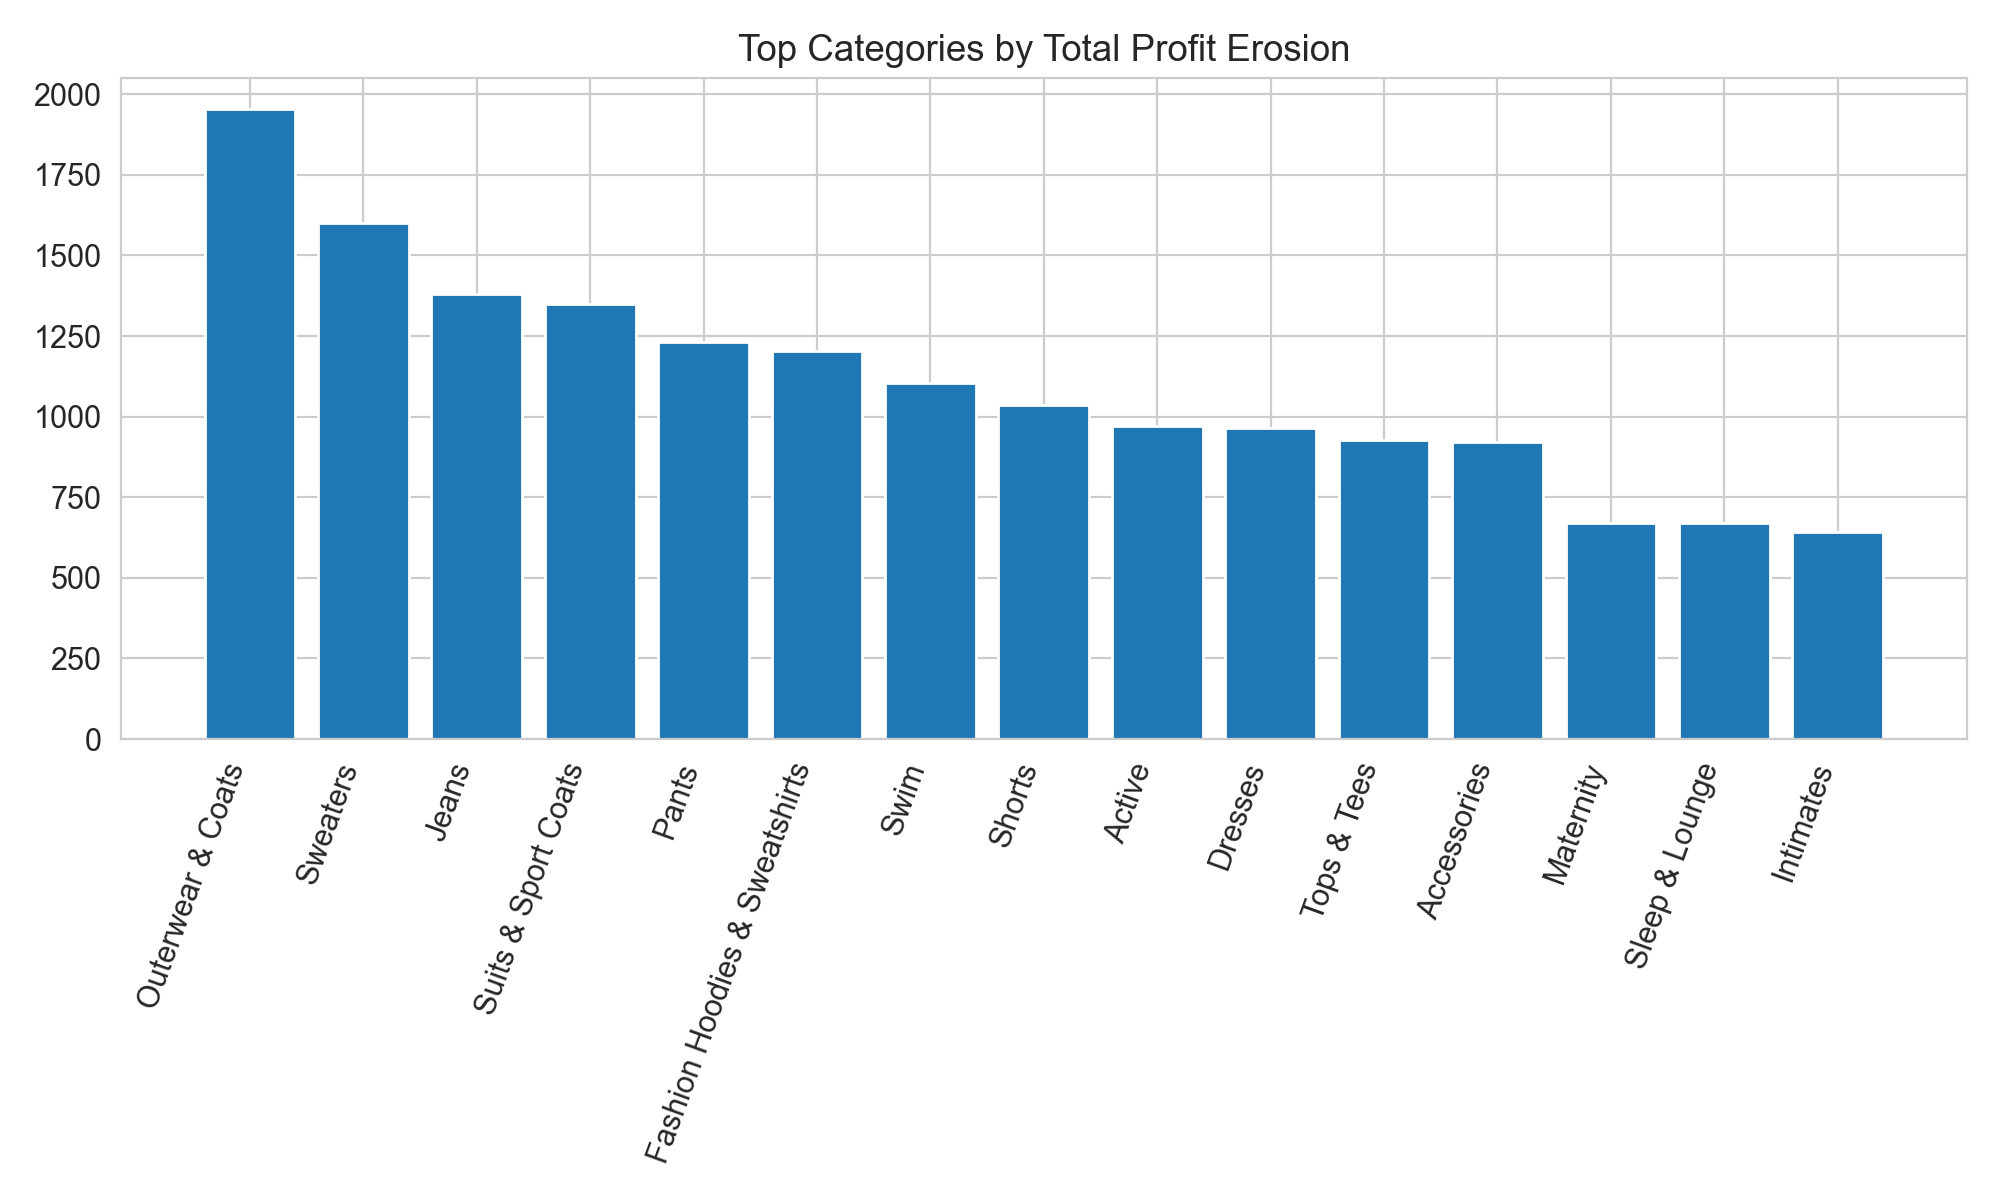

✅ Saved: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig1_top_categories_total_erosion.png


In [234]:
from IPython.display import display, Image
import matplotlib.pyplot as plt

out_path = RQ1_FIG_DIR / "fig1_top_categories_total_erosion.png"

rq1_visuals.plot_top_groups_total_erosion(
    erosion_cat,
    group_col="category",
    value_col="total_profit_erosion",
    top_n=15,
    out_path=out_path,
    title="Top Categories by Total Profit Erosion",
)

# Show saved image inline
if out_path.exists():
    display(Image(filename=str(out_path)))
else:
    print("⚠️ Figure file not found:", out_path)
print(f"✅ Saved: {out_path}")


## 6.9 RQ1 Figure 2 — Top Brands by Total Profit Erosion

Purpose:
Determine which brands contribute most to total erosion.
Supports brand-level segmentation analysis for RQ1.



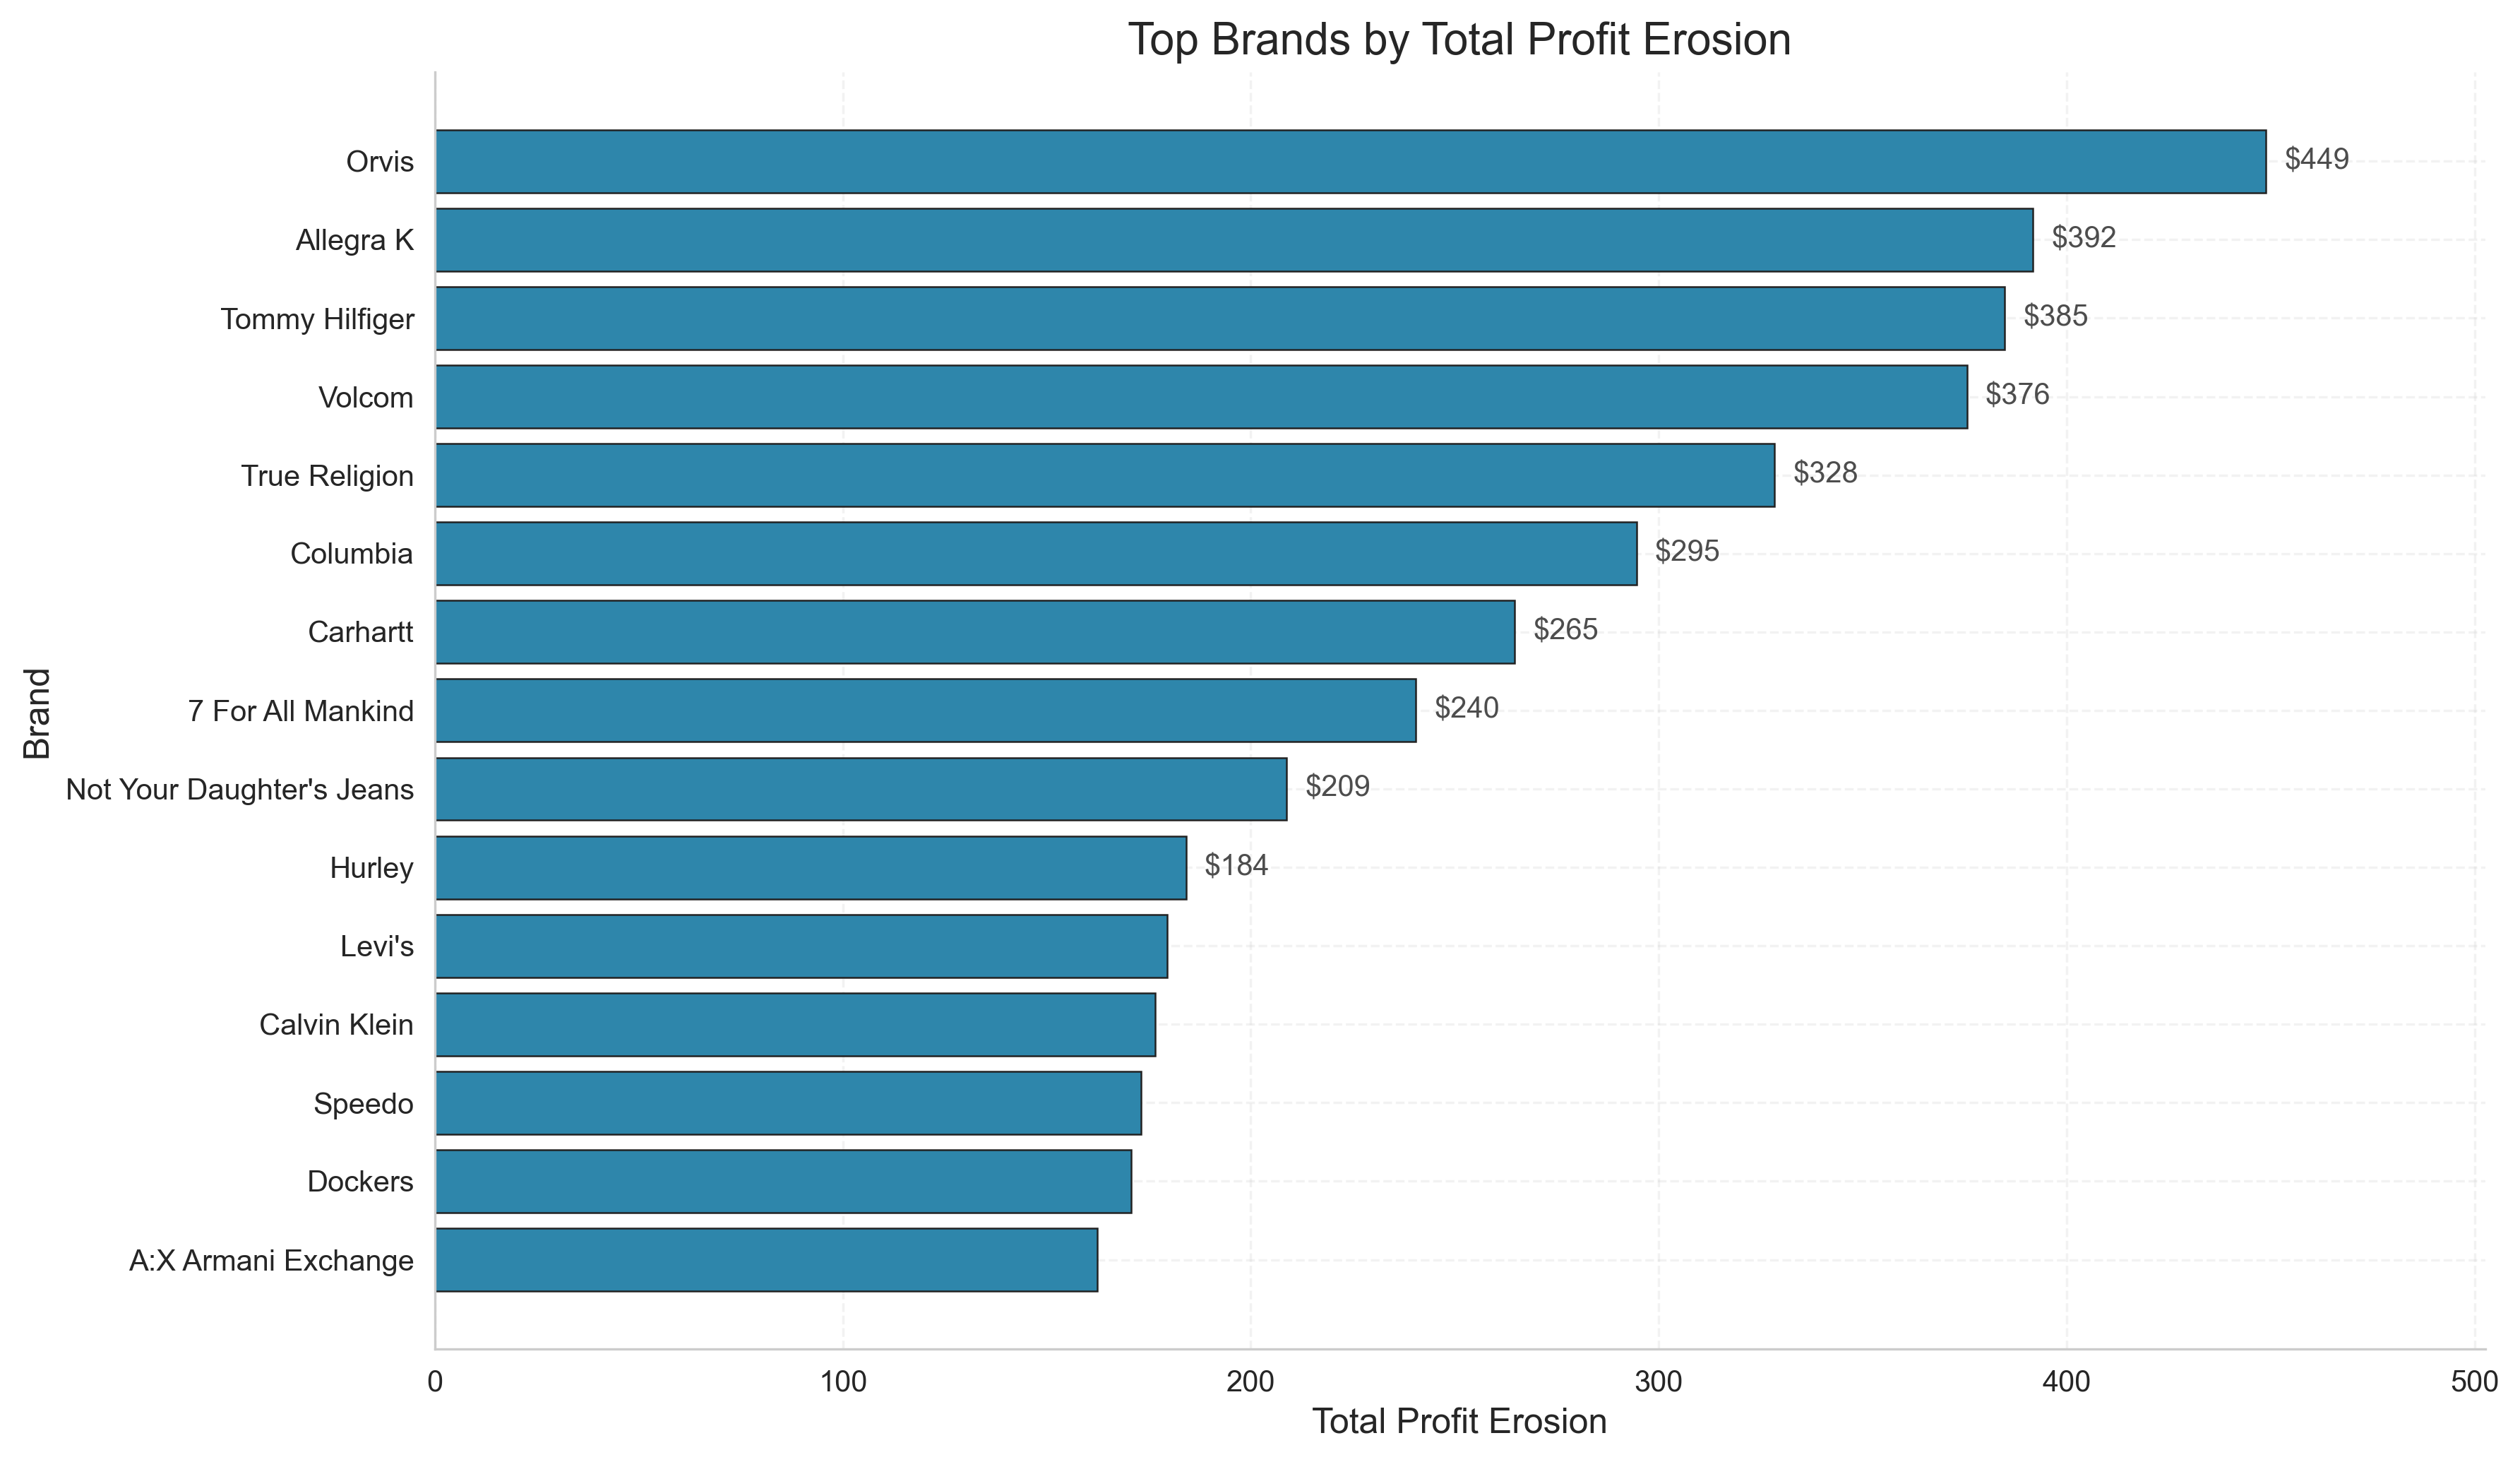

✅ Saved: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig2_top_brands_total_erosion.png


In [236]:
out_path = RQ1_FIG_DIR / "fig2_top_brands_total_erosion.png"

rq1_visuals.plot_top_groups_total_erosion(
    erosion_brand,
    group_col="brand",
    value_col="total_profit_erosion",
    top_n=15,
    out_path=out_path,
    title="Top Brands by Total Profit Erosion",
)

if out_path.exists():
    display(Image(filename=str(out_path)))

print(f"✅ Saved: {out_path}")


## 6.10 Figure 3 — Return Rate vs Mean Profit Erosion (Category)

Purpose:
This scatter plot distinguishes whether high total erosion categories
are driven by:

- High return frequency (return rate)
- High loss per returned item (mean erosion)
- Or both

Bubble size represents returned item volume.
Only top contributors are annotated for readability.


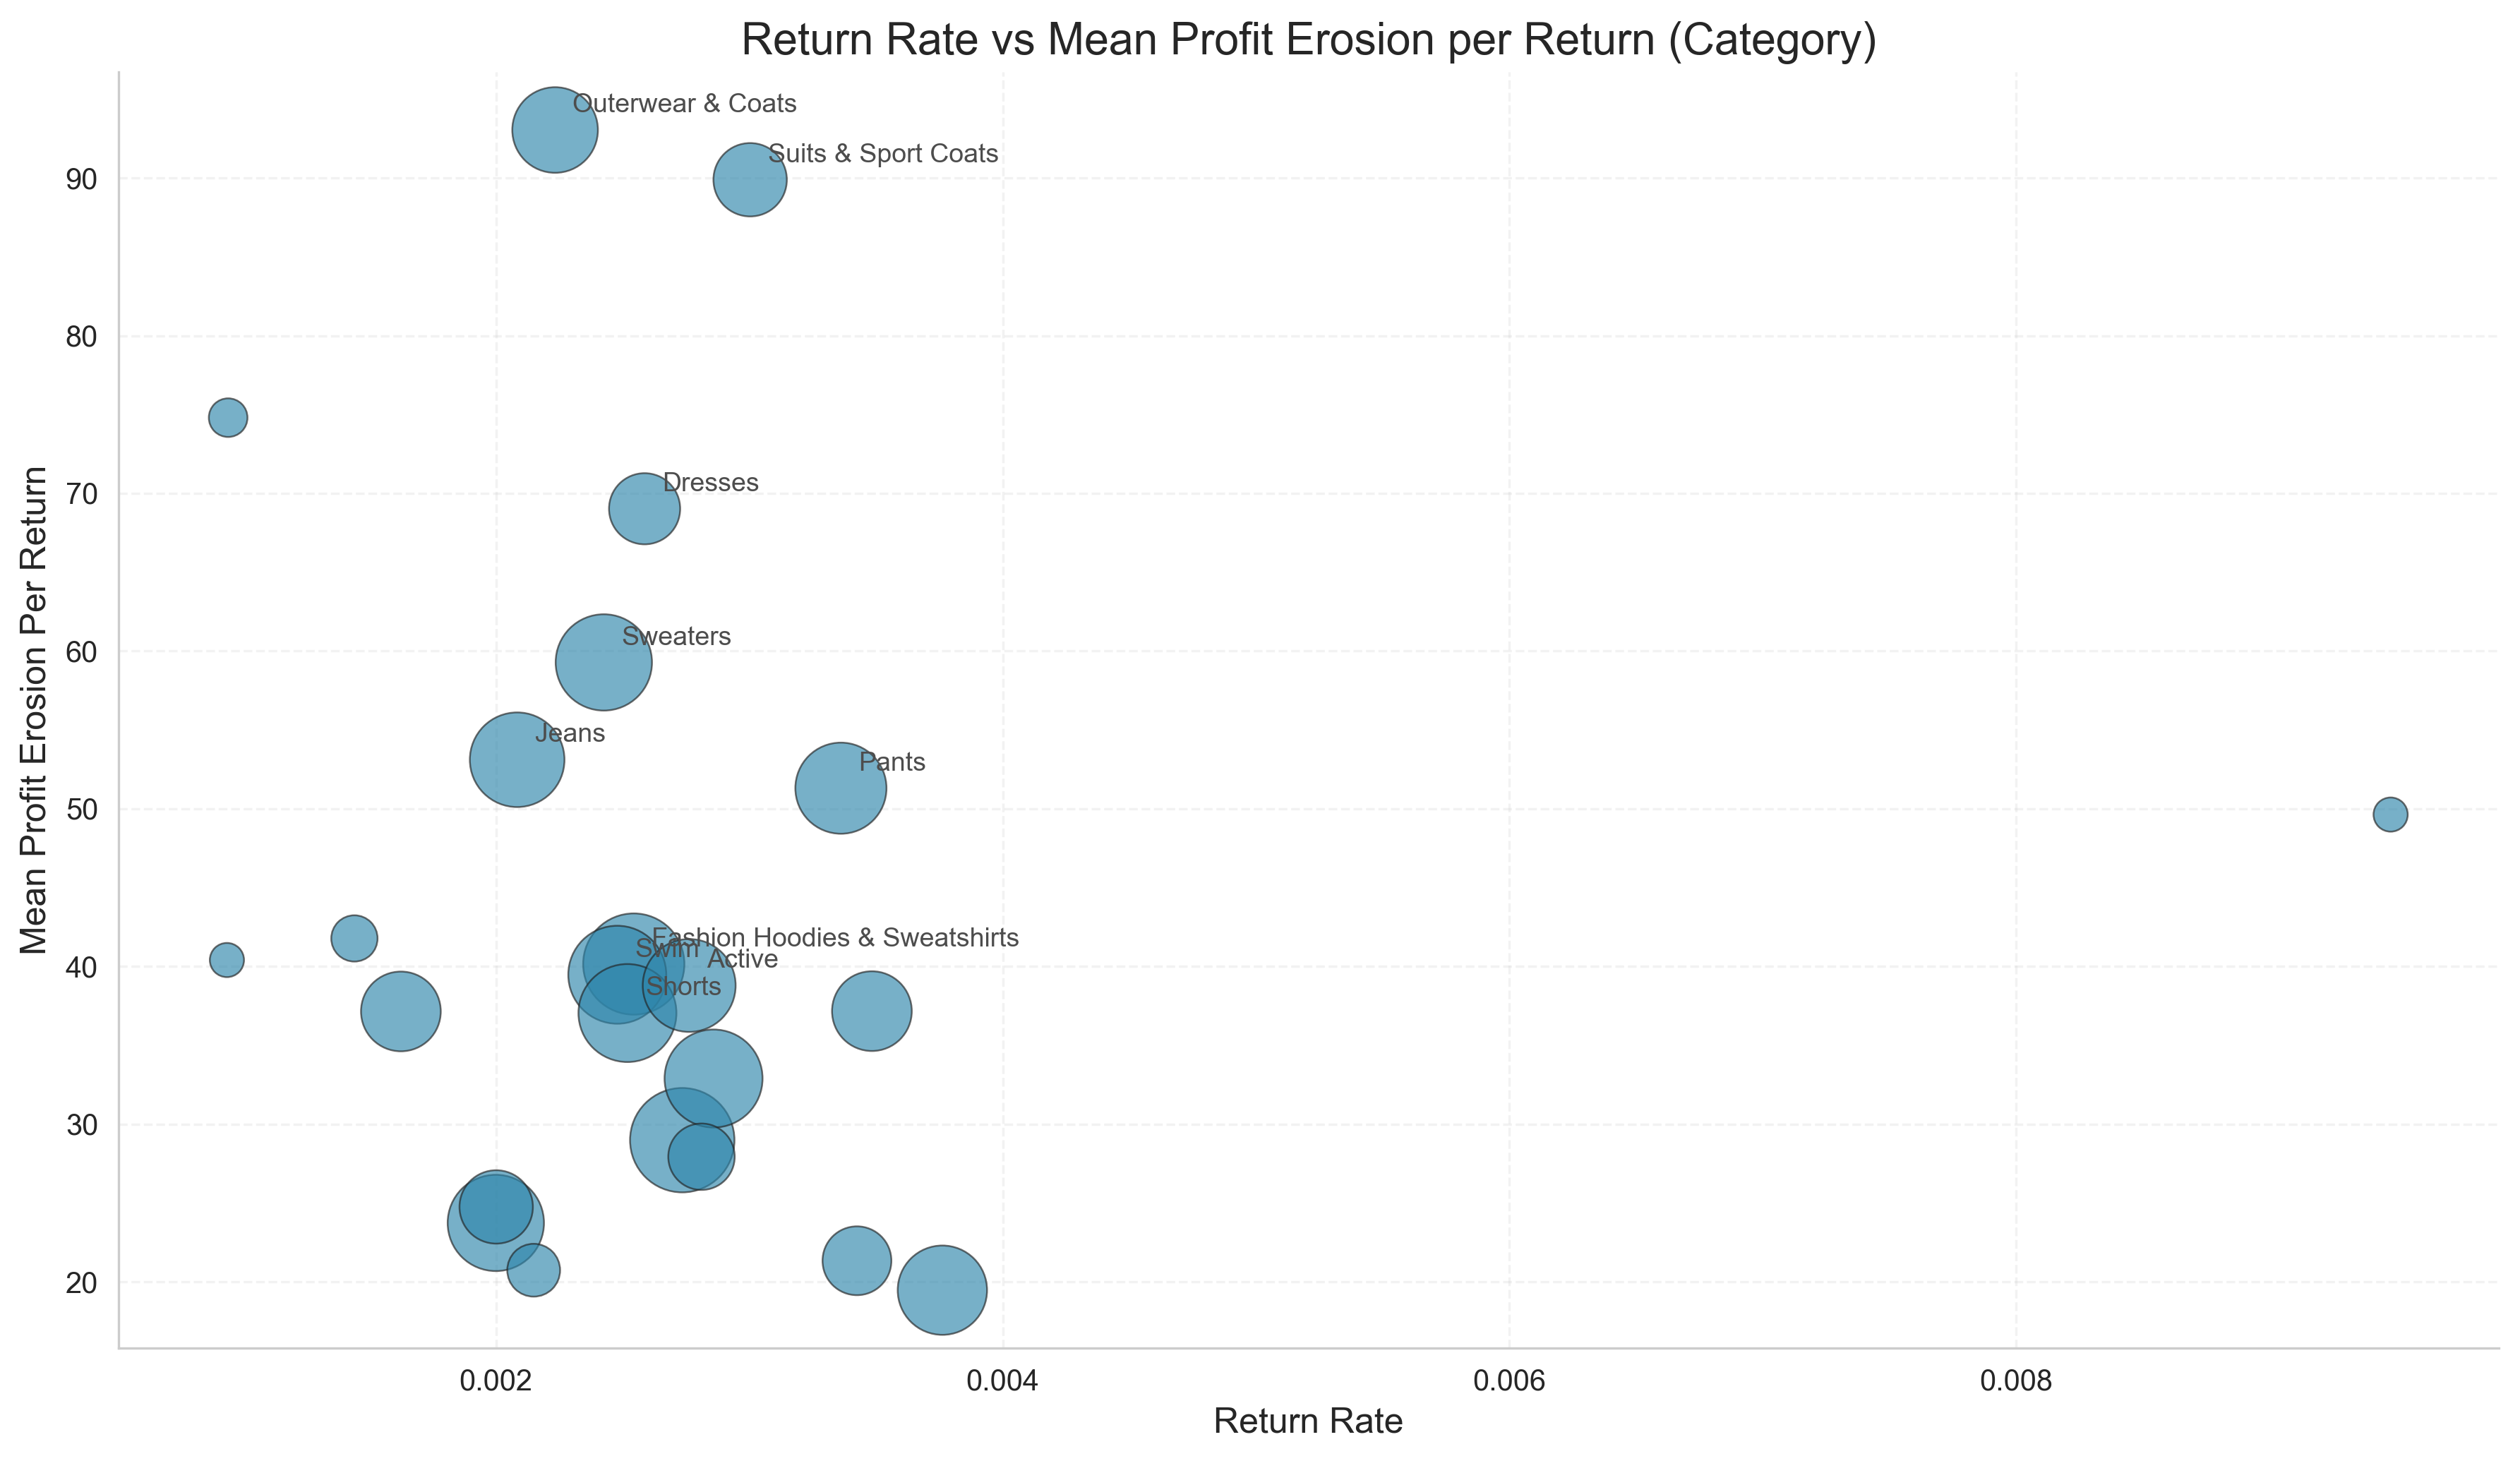

✅ Saved: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig3_return_rate_vs_mean_erosion_category.png


In [249]:
out_path = RQ1_FIG_DIR / "fig3_return_rate_vs_mean_erosion_category.png"

# Merge behavior data if available
behavior_cat_path = RQ1_OUT_DIR / "us07_product_return_behavior_by_category.parquet"

if behavior_cat_path.exists():
    cat_behavior = pd.read_parquet(behavior_cat_path)
    cat_plot_df = erosion_cat.merge(cat_behavior, on="category", how="left", suffixes=("", "_behavior"))
else:
    cat_plot_df = erosion_cat.copy()

# Standardize return_rate column if necessary
if "return_rate_behavior" in cat_plot_df.columns and "return_rate" not in cat_plot_df.columns:
    cat_plot_df = cat_plot_df.rename(columns={"return_rate_behavior": "return_rate"})

y_col = "mean_profit_erosion_per_return" if "mean_profit_erosion_per_return" in cat_plot_df.columns else "avg_profit_erosion"

rq1_visuals.plot_return_rate_vs_mean_erosion(
    cat_plot_df,
    x_col="return_rate",
    y_col=y_col,
    label_col="category",
    size_col="returned_items",
    out_path=out_path,
    title="Return Rate vs Mean Profit Erosion per Return (Category)",
    annotate_top_k=10,
)

if out_path.exists():
    display(Image(filename=str(out_path)))
else:
    print("⚠️ Figure file not found:", out_path)

print(f"✅ Saved: {out_path}")


## 6.11 RQ1 Figure 4 — Top Departments by Total Profit Erosion

Purpose:
Identify departmental concentration of erosion to support operational prioritization.



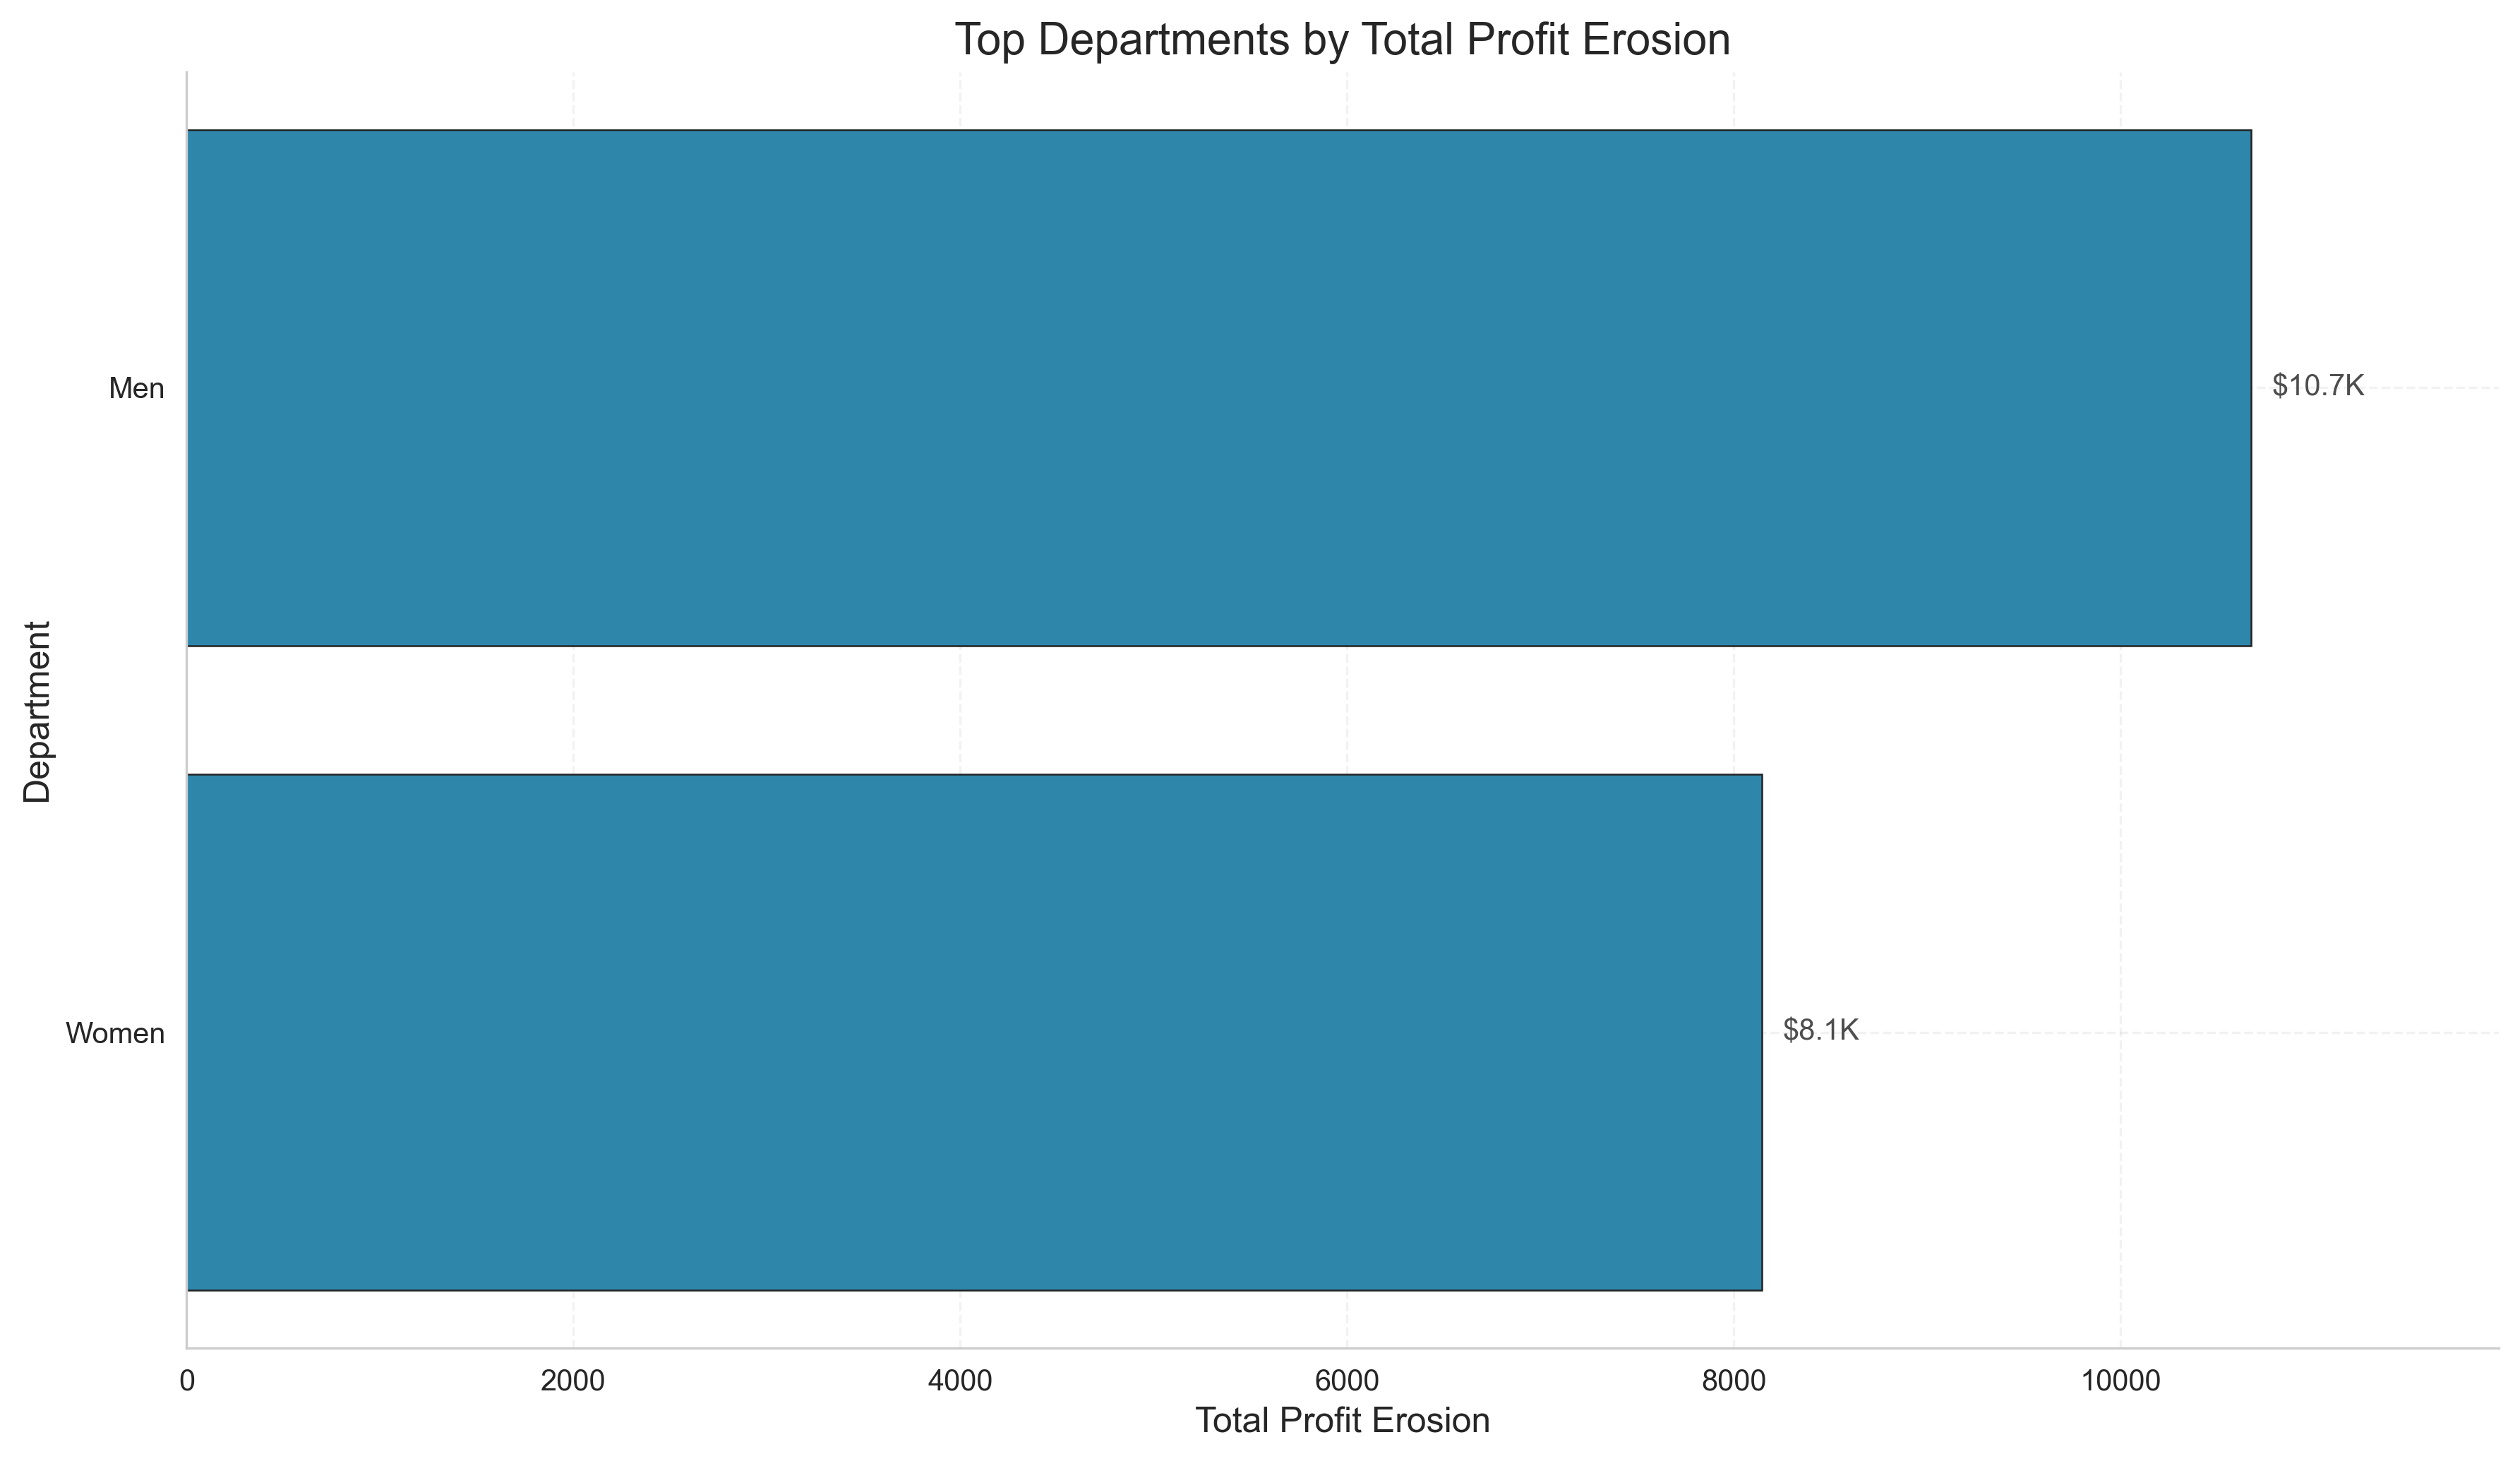

✅ Saved: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig4_top_departments_total_erosion.png


In [250]:
out_path = RQ1_FIG_DIR / "fig4_top_departments_total_erosion.png"

rq1_visuals.plot_top_groups_total_erosion(
    erosion_dept,
    group_col="department",
    value_col="total_profit_erosion",
    top_n=15,
    out_path=out_path,
    title="Top Departments by Total Profit Erosion",
)

if out_path.exists():
    display(Image(filename=str(out_path)))

print(f"✅ Saved: {out_path}")


## 6.12 RQ1 Figure 5 — Severity vs Volume Decomposition (Category)

Identity:
Total Profit Erosion = Returned Items × Average Erosion per Return

Purpose:
Determine whether high erosion is driven by return volume,
per-return severity, or both.

Annotations limited to top contributors for clarity.


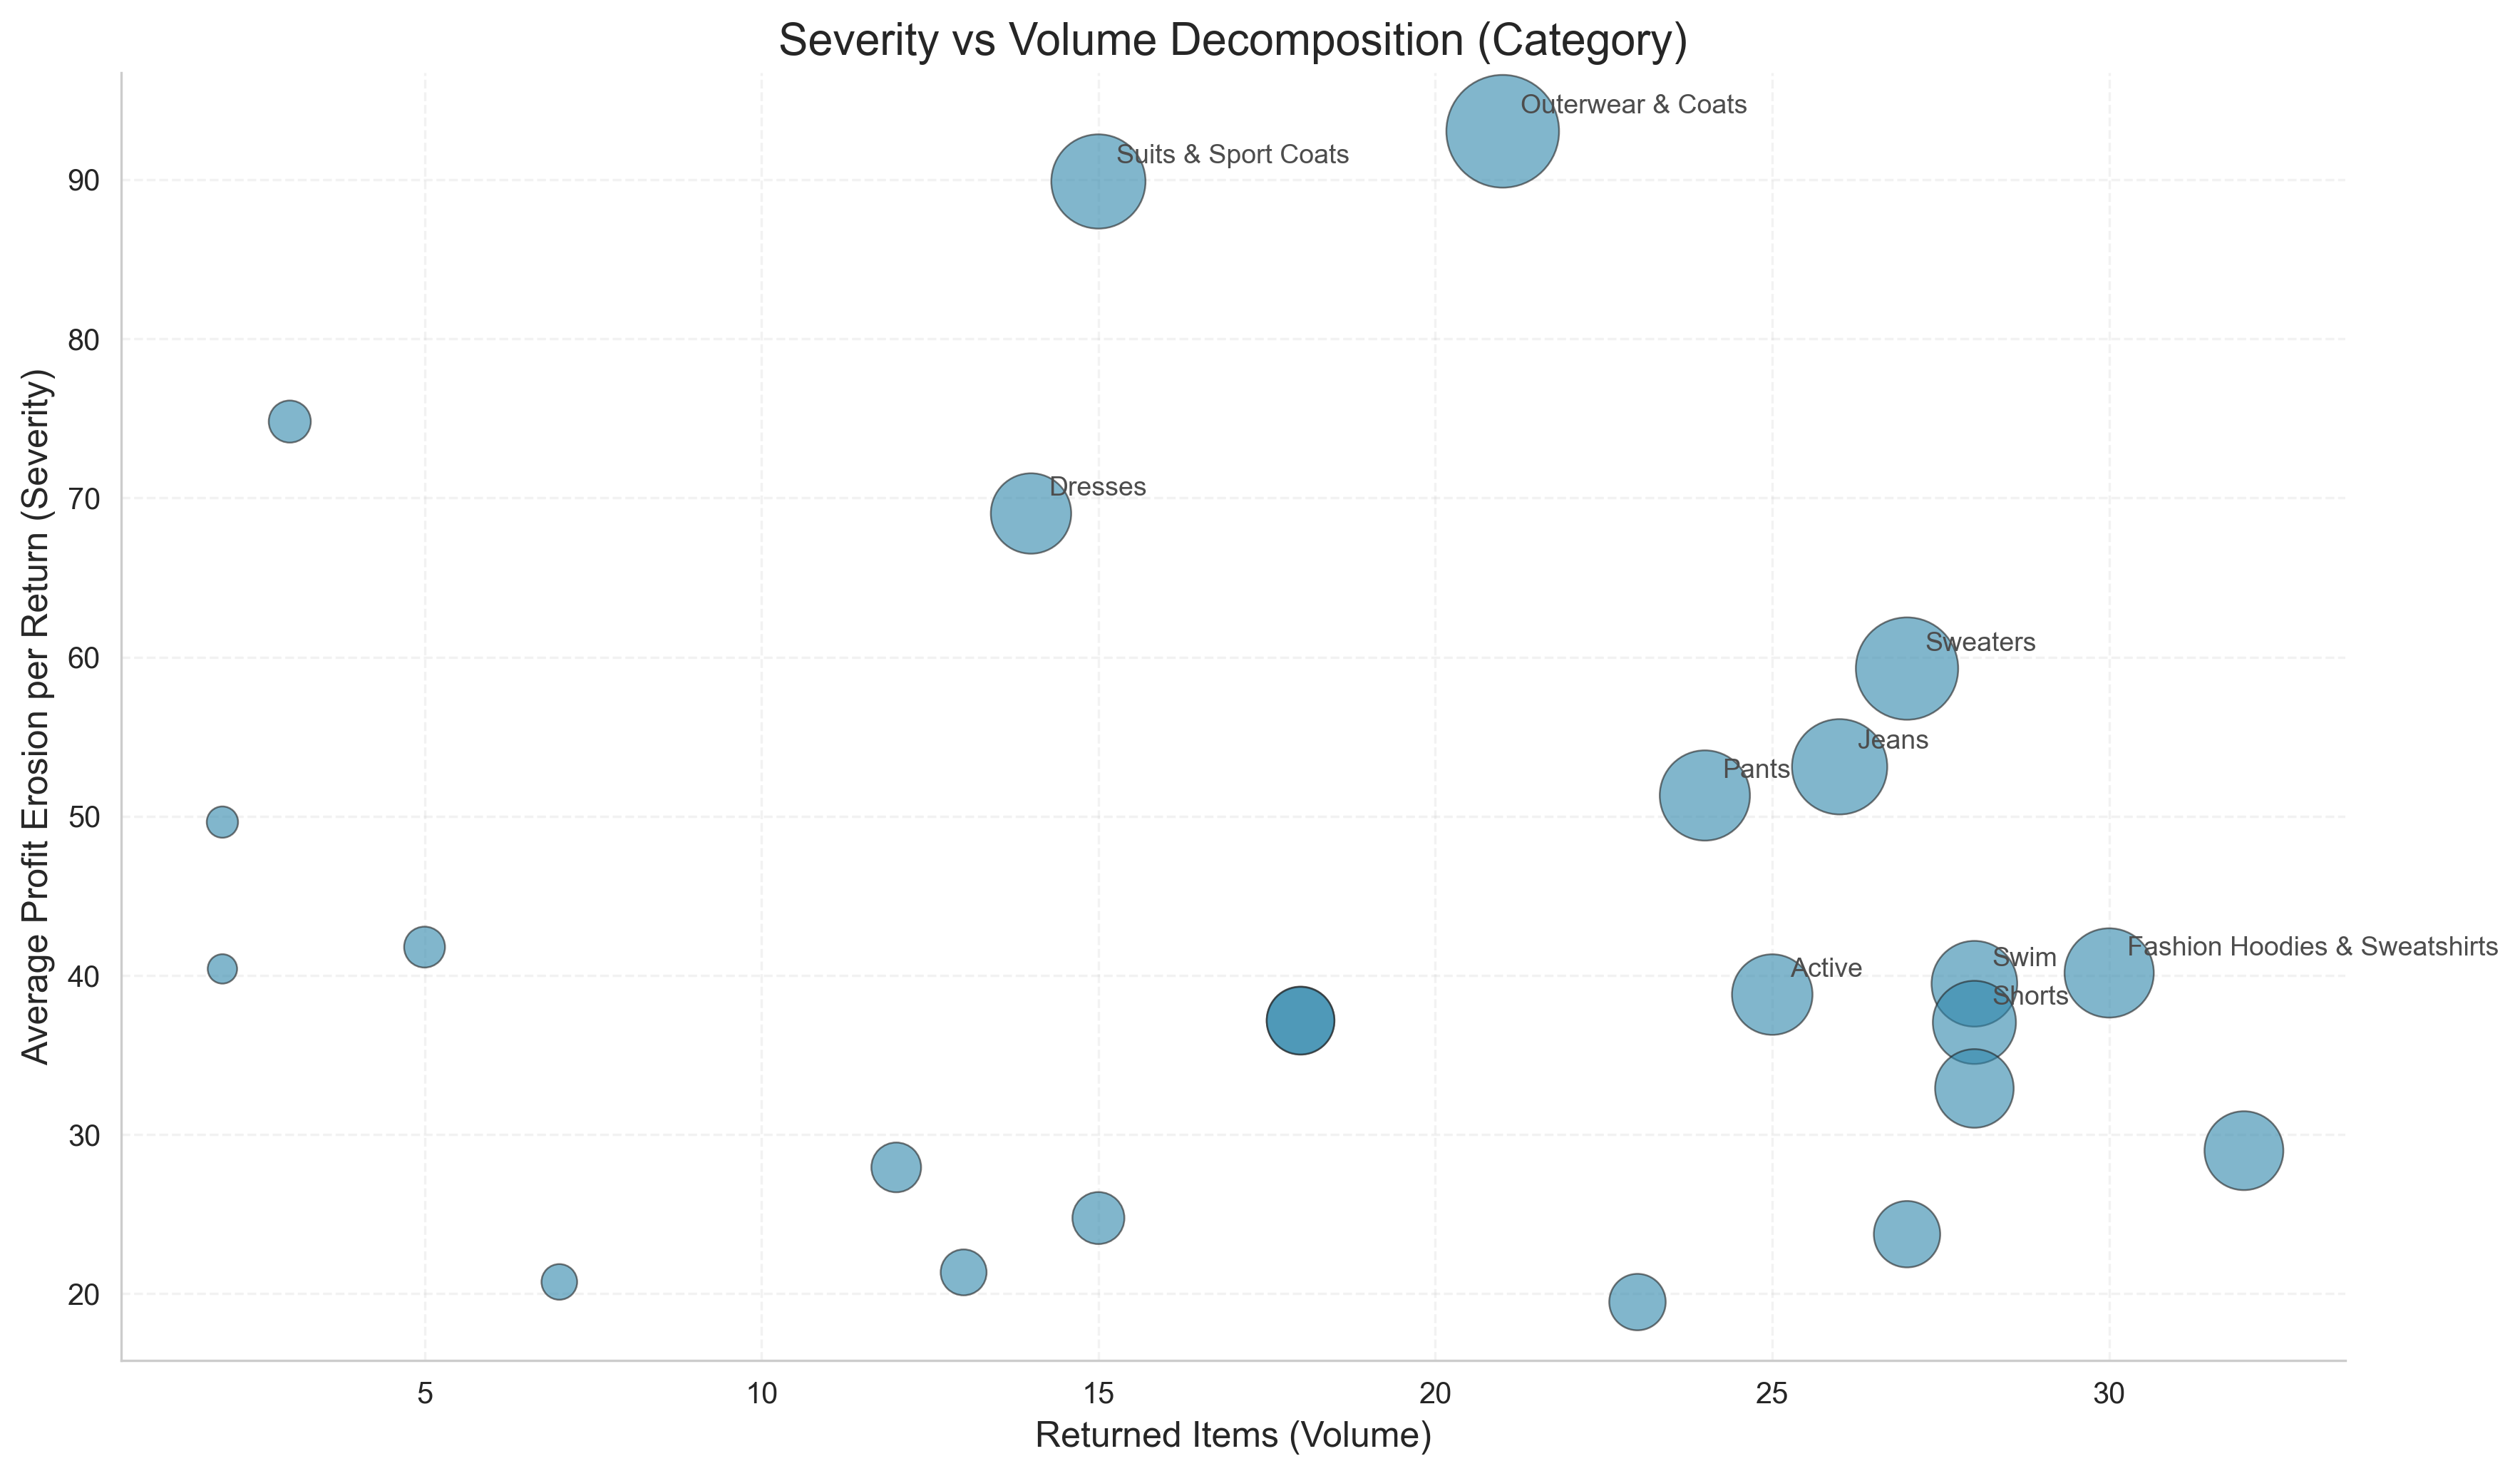

✅ Saved: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig5_severity_vs_volume_category.png


In [251]:
out_path = RQ1_FIG_DIR / "fig5_severity_vs_volume_category.png"

avg_erosion_col = "mean_profit_erosion_per_return" if "mean_profit_erosion_per_return" in erosion_cat.columns else "avg_profit_erosion"

rq1_visuals.plot_severity_vs_volume_decomposition(
    erosion_cat,
    group_col="category",
    returned_items_col="returned_items",
    avg_erosion_col=avg_erosion_col,
    total_erosion_col="total_profit_erosion",
    out_path=out_path,
    title="Severity vs Volume Decomposition (Category)",
    annotate_top_k=10,
)

if out_path.exists():
    display(Image(filename=str(out_path)))

print(f"✅ Saved: {out_path}")


## 6.13 Figure 6 — Distribution of Profit Erosion (Returned Items, Log Scale)

Purpose:
Demonstrate skewness and non-normality of item-level erosion values.

This supports the use of non-parametric statistical testing in RQ1.


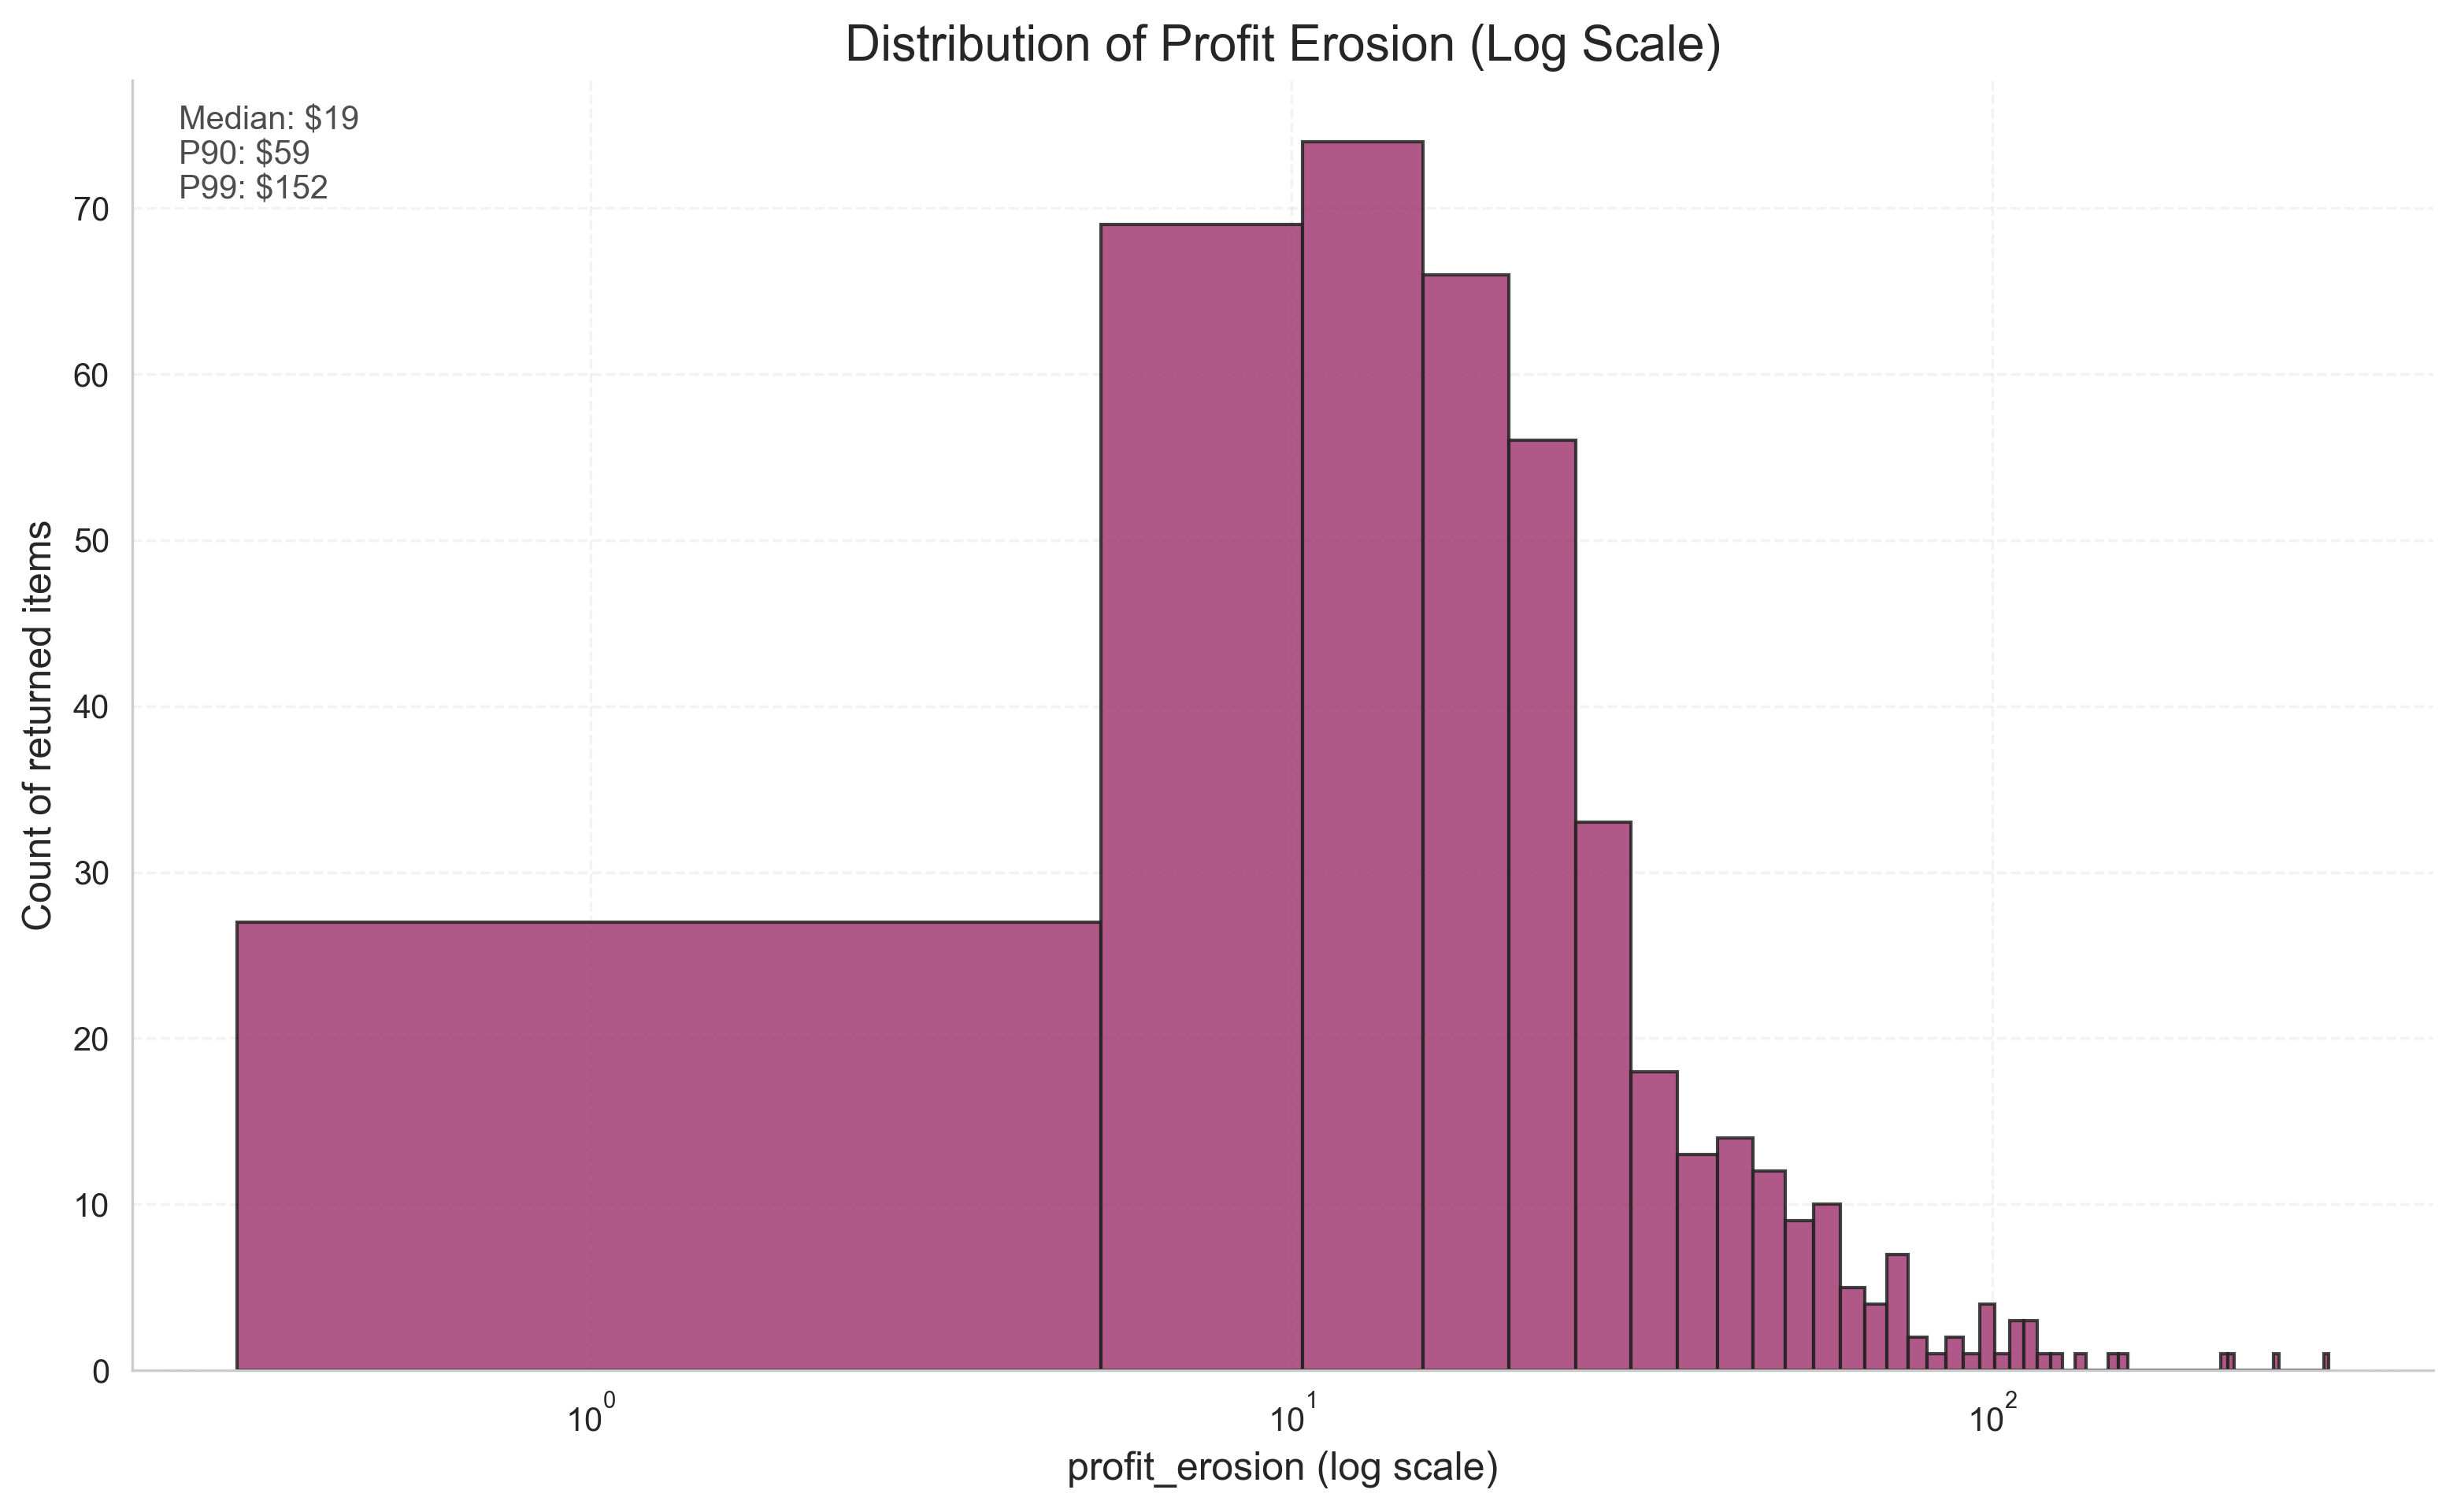

✅ Saved: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig6_profit_erosion_distribution_log.png


In [252]:
out_path = RQ1_FIG_DIR / "fig6_profit_erosion_distribution_log.png"

rq1_visuals.plot_profit_erosion_distribution_log(
    returned_df,
    value_col="profit_erosion",
    out_path=out_path,
    title="Distribution of Profit Erosion (Log Scale)",
    bins=60,
)

if out_path.exists():
    display(Image(filename=str(out_path)))

print(f"✅ Saved: {out_path}")


## 6.14 RQ1 Figure 7 — Bootstrap 95% Confidence Intervals (Category Mean Erosion)

Purpose:
Quantify uncertainty around mean profit erosion per category.

This strengthens inference robustness beyond p-values.
The CI table is saved for documentation and reporting.


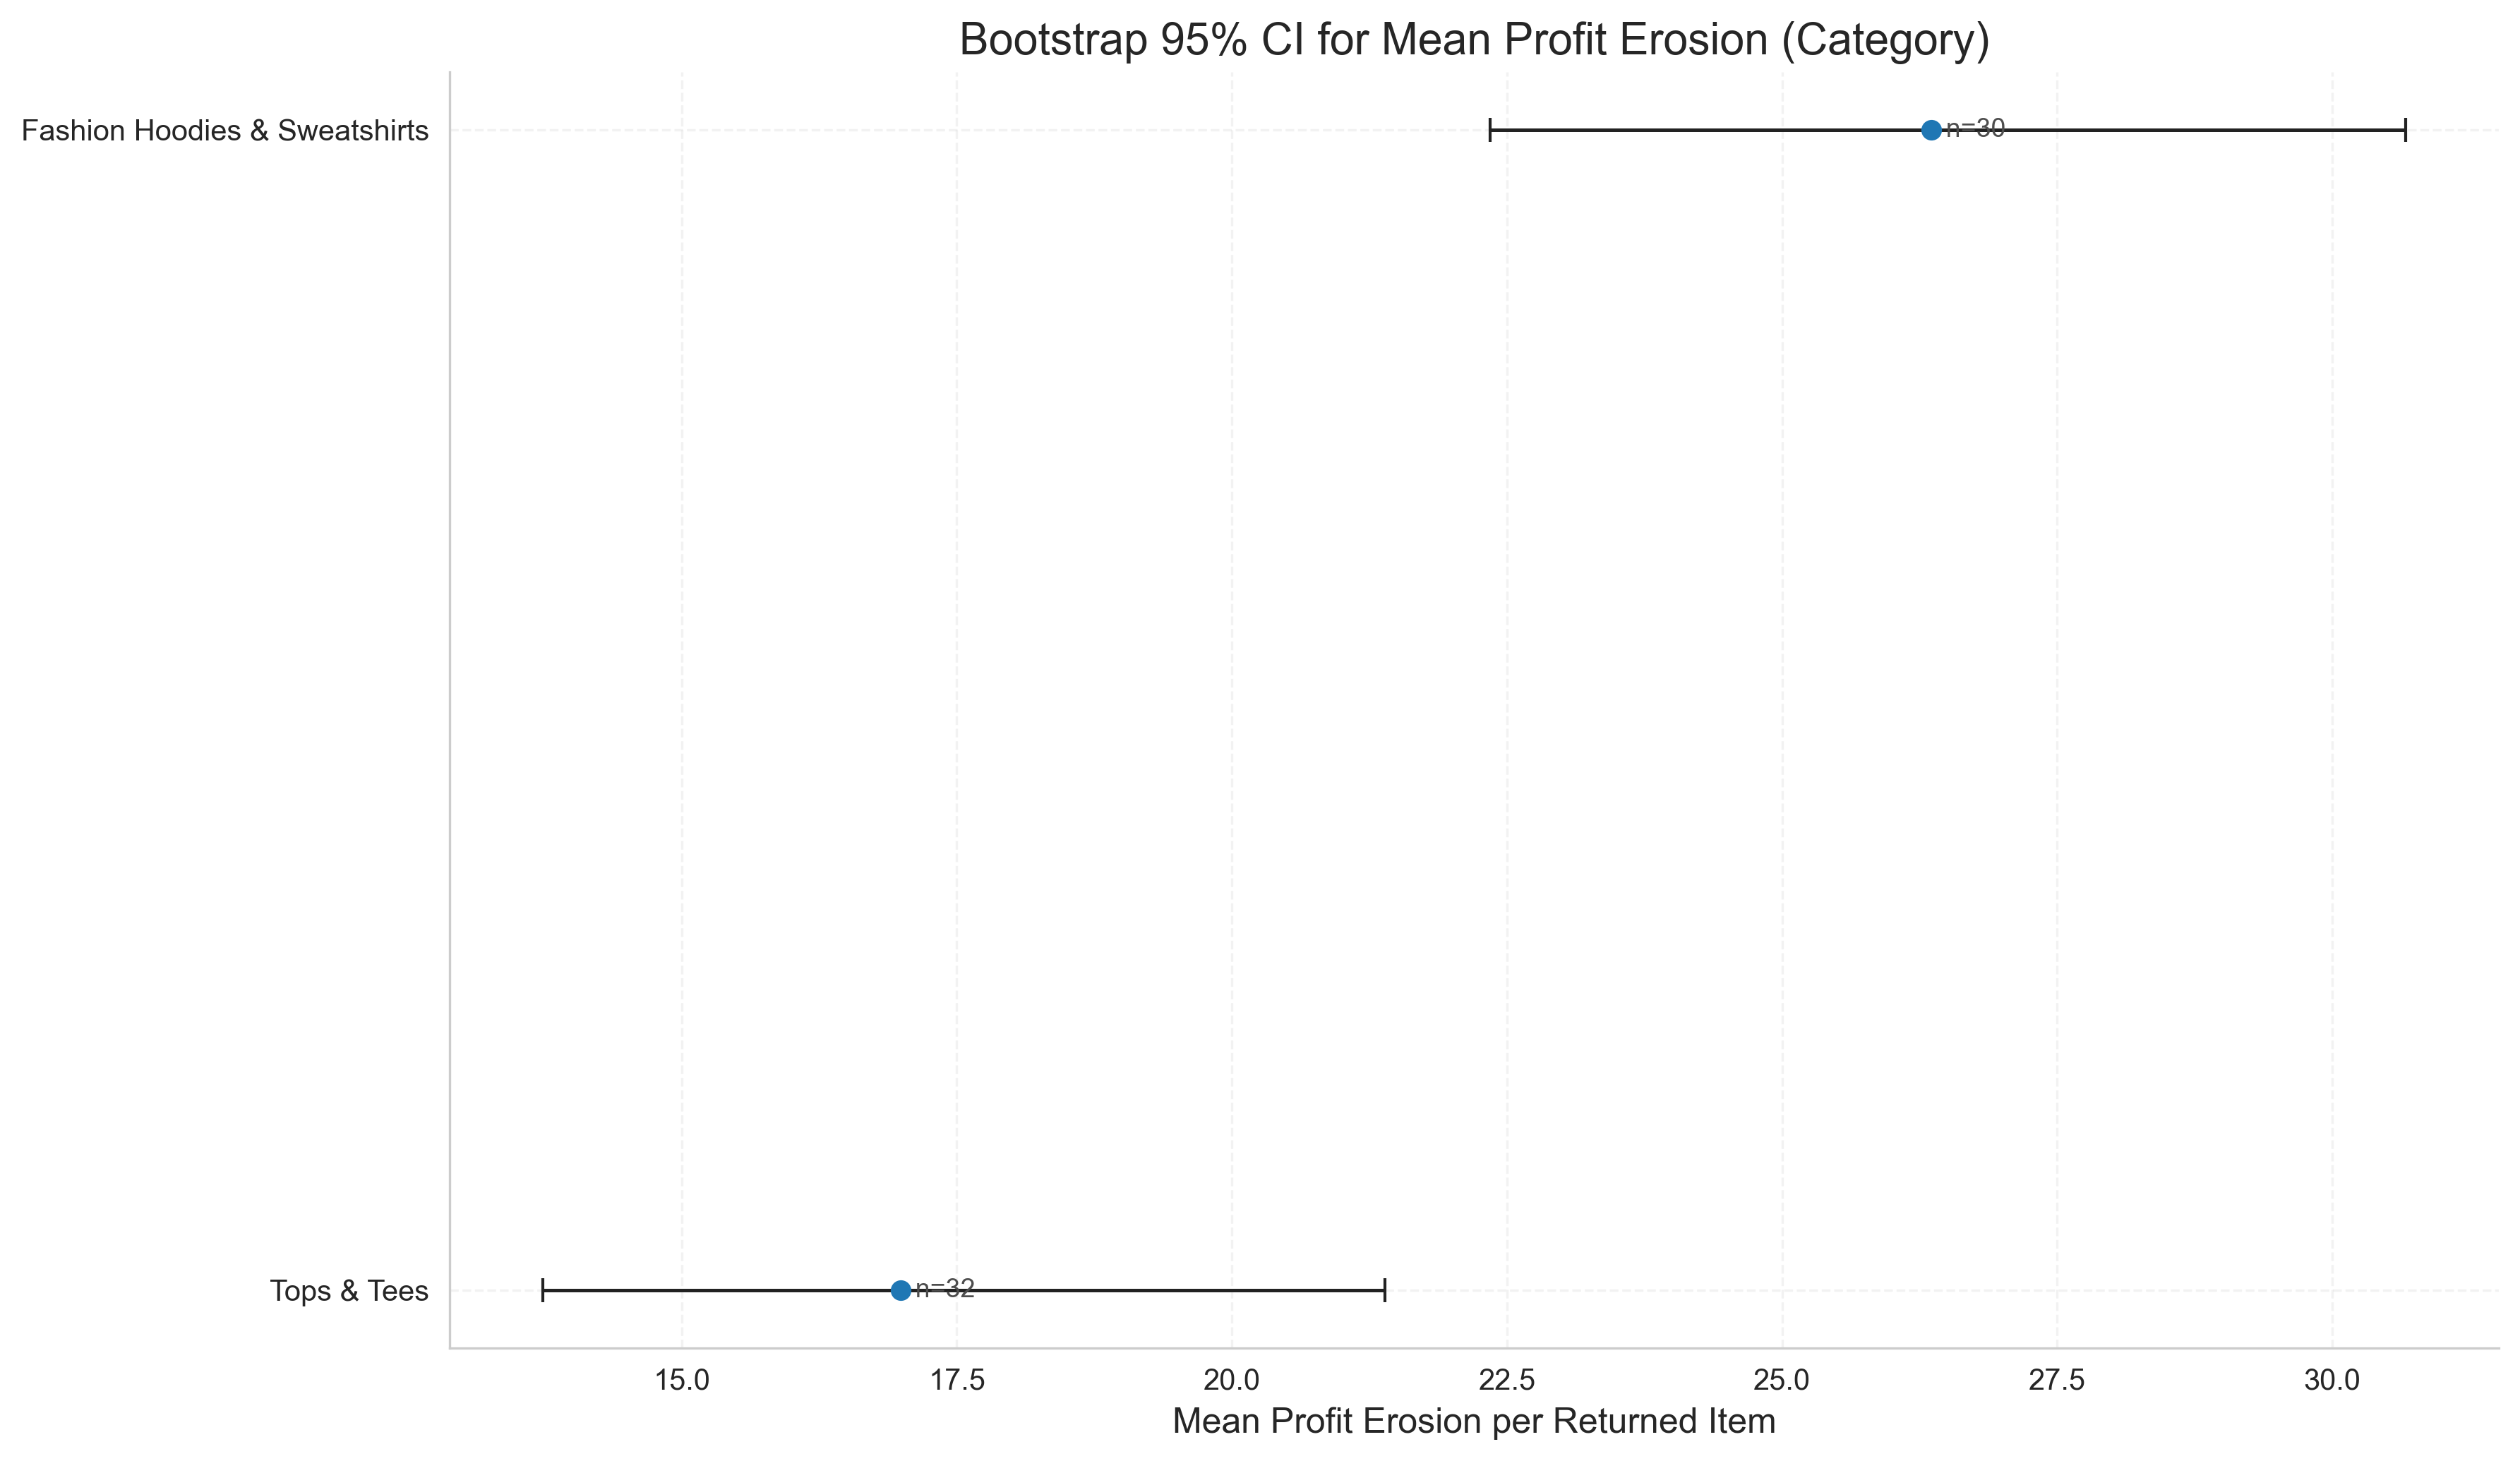

✅ Saved figure: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\figures\rq1\fig7_bootstrap_ci_category_mean.png
✅ Saved CI table: D:\Users\RSM\Downloads\Data Analytics\Capstone\V2\unfc-capstone-project\data\processed\rq1\rq1_bootstrap_ci_category_mean.parquet


,category,n_returned_items,mean_profit_erosion,ci_low_95,ci_high_95,ci_width
0,Fashion Hoodies & Sweatshirts,30,26.357747,22.345121,30.667009,8.321888
1,Tops & Tees,32,16.990719,13.740752,21.390423,7.649671


In [254]:
out_path = RQ1_FIG_DIR / "fig7_bootstrap_ci_category_mean.png"

ci_df, _ = rq1_visuals.plot_bootstrap_ci_mean_by_group(
    returned_df,
    group_col="category",
    value_col="profit_erosion",
    out_path=out_path,
    title="Bootstrap 95% CI for Mean Profit Erosion (Category)",
    n_boot=800,
    min_group_size=30,
    top_n_plot=15,
    random_state=42,
)

ci_table_path = RQ1_OUT_DIR / "rq1_bootstrap_ci_category_mean.parquet"
ci_df.to_parquet(ci_table_path, index=False)

if out_path.exists():
    display(Image(filename=str(out_path)))

print(f"✅ Saved figure: {out_path}")
print(f"✅ Saved CI table: {ci_table_path}")

ci_df.head()


---

## 6. RQ2: Customer Segmentation

**Research Question**: What customer behavioral segments exist with differential profit erosion?

### 6.1 Customer Behavior Profile

In [ ]:
# Customer behavior profile (using US06 customer features)
print("=" * 60)
print("CUSTOMER BEHAVIOR PROFILE")
print("=" * 60)

# Use customer_df which includes behavioral features and erosion
print(f"\nTotal customers: {len(customer_df):,}")
print(f"Customers with returns: {(customer_df['return_frequency'] > 0).sum():,}")

# Display summary of customer behavior
print("\n📊 Customer Behavior Summary:")
behavior_summary = customer_df[["order_frequency", "return_frequency", "customer_return_rate", 
                                 "avg_order_value", "total_profit_erosion"]].describe().round(2)
behavior_summary

CUSTOMER BEHAVIOR PROFILE

Total customers: 79,944
Customers with returns: 11,988

📊 Customer Behavior Summary:


,order_frequency,return_frequency,customer_return_rate,avg_order_value,total_profit_erosion
count,79944.00,79944.00,79944.00,79944.00,79944.00
mean,1.56,0.23,0.10,86.69,10.21
std,0.86,0.64,0.27,83.27,33.64
min,1.00,0.00,0.00,0.49,0.00
25%,1.00,0.00,0.00,35.00,0.00
50%,1.00,0.00,0.00,62.49,0.00
75%,2.00,0.00,0.00,110.00,0.00
max,4.00,8.00,1.00,1724.99,729.29


### 6.2 Customer Segmentation by Return Behavior

In [ ]:
# Segment customers by return behavior
customer_segments = segment_customers_by_return_behavior(
    df, 
    return_rate_thresholds=(0.05, 0.15)
)

# Segment distribution
segment_counts = customer_segments["return_segment"].value_counts()
print("Customer Segment Distribution:")
print(segment_counts)
print(f"\nTotal customers: {len(customer_segments):,}")

Customer Segment Distribution:
return_segment
no_returns           67956
high_returner        11718
moderate_returner      270
Name: count, dtype: int64

Total customers: 79,944


In [ ]:
# Analyze segments
segment_summary = (
    customer_segments
    .groupby("return_segment")
    .agg(
        customer_count=("total_items", "count"),
        avg_items=("total_items", "mean"),
        # avg_returns=("return_events", "mean"),
        avg_return_rate=("customer_return_rate", "mean"),
        total_margin=("total_margin", "sum"),
    )
    .round(2)
)
segment_summary

,customer_count,avg_items,avg_return_rate,total_margin
return_segment,,,,
high_returner,11718,2.76,0.68,998687.15
moderate_returner,270,7.54,0.13,62615.91
no_returns,67956,2.16,0.00,4554085.07


### 6.3 Customer Margin Exposure

In [ ]:
# Customer margin exposure
customer_exposure = calculate_customer_margin_exposure(df)
customer_exposure.head(20)

,return_events,total_lost_margin,total_lost_sales,median_margin_per_return,max_single_return_margin
user_id,,,,,
46358,5,660.286698,1230.989998,36.476199,507.485999
73088,4,601.724230,1030.820002,29.405225,535.478999
9592,2,560.598027,991.769997,280.299013,503.873999
73720,2,555.082019,945.990002,277.541010,533.672998
48158,2,545.759348,925.990000,272.879674,532.769998
34216,1,535.478999,903.000000,535.478999,535.478999
79918,2,534.529997,1040.000000,267.264999,511.829997
7008,1,533.672998,903.000000,533.672998,533.672998
51888,1,532.769998,903.000000,532.769998,532.769998


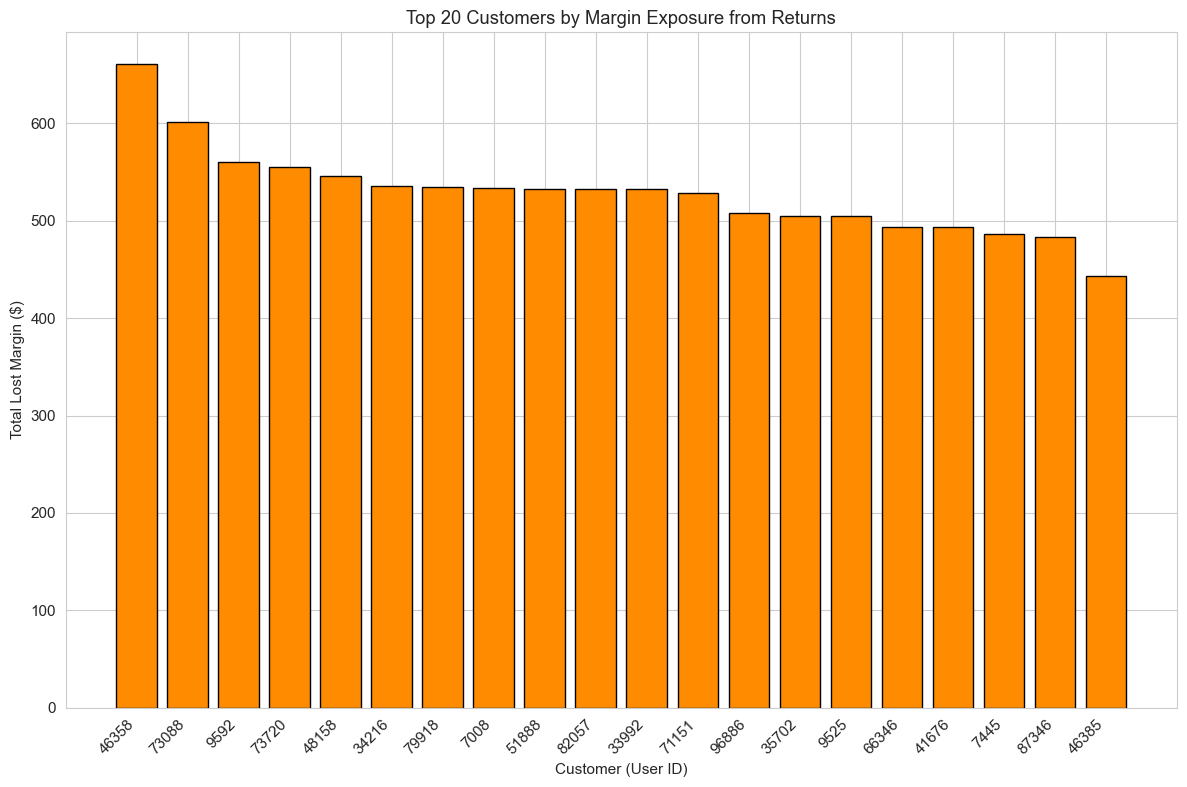

In [ ]:
# Visualize customer margin exposure
fig = plot_customer_margin_exposure(df, top_n=20)
plt.show()

---

## 7. RQ3: Predictive Modeling

**Research Question**: Can we predict high profit erosion customers with AUC > 0.70?

*TODO: Implement predictive modeling*

In [ ]:
# RQ3: Predictive Modeling - Data Ready
print("=" * 60)
print("RQ3: PREDICTIVE MODELING - DATA PREPARED")
print("=" * 60)

print("\n✅ Target variable created: is_high_erosion_customer")
print(f"   - Threshold: 75th percentile (${threshold:.2f})")
print(f"   - High erosion customers: {customer_targets['is_high_erosion_customer'].sum():,}")
print(f"   - Normal customers: {(customer_targets['is_high_erosion_customer'] == 0).sum():,}")

print("\n✅ Features available for modeling:")
feature_cols = [col for col in customer_targets.columns 
                if col not in ["user_id", "is_high_erosion_customer", "profit_erosion_quartile", 
                               "erosion_percentile_rank", "total_profit_erosion"]]
for col in feature_cols[:10]:
    print(f"   - {col}")
if len(feature_cols) > 10:
    print(f"   ... and {len(feature_cols) - 10} more")

print("\n📋 Next Steps:")
print("  1. Feature selection and preprocessing")
print("  2. Train/test split with temporal consideration")
print("  3. Model training (Logistic Regression, Random Forest, XGBoost)")
print("  4. Evaluation metrics (target AUC > 0.70)")

RQ3: PREDICTIVE MODELING - DATA PREPARED

✅ Target variable created: is_high_erosion_customer
   - Threshold: 75th percentile ($85.92)
   - High erosion customers: 2,997
   - Normal customers: 8,991

✅ Features available for modeling:
   - total_items
   - order_frequency
   - return_frequency
   - total_sales
   - total_margin
   - avg_item_price
   - avg_item_margin
   - customer_return_rate
   - avg_basket_size
   - purchase_recency_days
   ... and 4 more

📋 Next Steps:
  1. Feature selection and preprocessing
  2. Train/test split with temporal consideration
  3. Model training (Logistic Regression, Random Forest, XGBoost)
  4. Evaluation metrics (target AUC > 0.70)


---

## 8. RQ4: Econometric Analysis

**Research Question**: What are the marginal associations between customer behaviors and profit erosion?

*TODO: Implement regression analysis*

In [ ]:
# Placeholder for econometric analysis
print("RQ4: Econometric Regression - To be implemented")
print("\nPlanned approach:")
print("  1. Define dependent variable (profit erosion per customer)")
print("  2. Select independent variables (demographics, behavior metrics)")
print("  3. OLS regression with robust standard errors")
print("  4. Coefficient interpretation and marginal effects")
print("  5. Model diagnostics (heteroscedasticity, multicollinearity)")

RQ4: Econometric Regression - To be implemented

Planned approach:
  1. Define dependent variable (profit erosion per customer)
  2. Select independent variables (demographics, behavior metrics)
  3. OLS regression with robust standard errors
  4. Coefficient interpretation and marginal effects
  5. Model diagnostics (heteroscedasticity, multicollinearity)


---

## 9. Summary & Conclusions

*To be completed after all analyses*

In [ ]:
# US06 Feature Engineering Summary
print("=" * 60)
print("US06 FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset Statistics:")
print(f"  Total order items: {len(df):,}")
print(f"  Returned items: {len(df_returned):,}")
print(f"  Return rate: {len(df_returned) / len(df) * 100:.2f}%")

print(f"\n💰 Profit Erosion (Category-Tiered Costs):")
print(f"  Total margin reversal: ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"  Total processing costs: ${erosion_summary['total_process_costs']:,.2f}")
print(f"  TOTAL PROFIT EROSION: ${erosion_summary['total_profit_erosion']:,.2f}")

print(f"\n👥 Customer Analysis:")
print(f"  Total customers: {len(customer_df):,}")
print(f"  Customers with returns: {len(customer_targets):,}")
print(f"  High erosion customers (Q4): {customer_targets['is_high_erosion_customer'].sum():,}")

print(f"\n✅ Datasets Saved:")
print(f"  - feature_engineered_dataset.parquet ({len(df):,} rows)")
print(f"  - customer_profit_erosion_targets.parquet ({len(customer_targets):,} rows)")

print("\n" + "=" * 60)

US06 FEATURE ENGINEERING SUMMARY

📊 Dataset Statistics:
  Total order items: 180,908
  Returned items: 18,208
  Return rate: 10.06%

💰 Profit Erosion (Category-Tiered Costs):
  Total margin reversal: $564,294.54
  Total processing costs: $252,206.40
  TOTAL PROFIT EROSION: $816,500.94

👥 Customer Analysis:
  Total customers: 79,944
  Customers with returns: 11,988
  High erosion customers (Q4): 2,997

✅ Datasets Saved:
  - feature_engineered_dataset.parquet (180,908 rows)
  - customer_profit_erosion_targets.parquet (11,988 rows)

